<h1 align="center">Time Series Analysis of Brent Crude Oil Prices</h1>
<h3 align="center">Forecasting Monthly Prices Using ARIMA Models (1987–2026)</h3>

---

<p align="center">
<b>Course:</b> Time Series Analysis and Classification — TSAC 2025/2026 <br>
<b>Institution:</b> National School of Artificial Intelligence — ENSIA <br>
<b>Date:</b> March 2025
</p>

---

## Abstract

*To be completed after the full analysis is finished.*




<br>

## **1.Introduction**

Brent Crude Oil is a light, sweet crude extracted from the North Sea, and 
the world's main oil price benchmark, used to price around 70% of globally 
traded oil. Its price affects the cost of fuel, transport, food, and 
manufactured goods in virtually every country. For Algeria specifically, 
oil exports make up the majority of government revenue, meaning Brent price 
movements directly impact the national budget and economy. Being able to model and forecast this price is therefore of direct practical relevance for economic planning and policy decisions.

The dataset used in this project contains 465 monthly observations of the 
Brent Crude Oil spot price in US dollars per barrel, downloaded from the 
Federal Reserve Economic Data platform (FRED). It covers June 1987 to 
February 2026 , a period that includes major global events such as the 1990 
Gulf War, the 2008 financial crisis, the 2020 COVID-19 crash, and the 2022 
Ukraine war, all of which produced sharp movements in the price series.

This study applies statistical ARIMA models to characterize the behavior 
of the series and generate future price forecasts. The analysis covers data 
preparation, stationarity testing, model identification, fitting, diagnostic 
checking, and forecast evaluation against withheld observations.

**Dataset:** [Brent Crude Oil Monthly Prices — FRED via Google Drive](
https://drive.google.com/file/d/1ZzDUur0XT4rl1_QCZAT2kvuy8yUH2Ou2/view?usp=sharing)
<br>

## **2.Model Specification**

This section describes the full process used to identify candidate models 
for the Brent Crude Oil price series. It covers data preparation, visual 
inspection, variance stabilization, stationarity testing, and ACF/PACF 
analysis. Each step builds on the previous one and leads to a justified 
selection of candidate ARIMA models.

<h3 style="font-weight:800;">2.1 Data Preparation</h3>
Before any analysis begins, the dataset is loaded, inspected, and 
converted into a proper time series object. This step verifies that 
the data is complete, correctly formatted, and ready for analysis.

In [108]:
# Load libraries 
library(tseries)    # ADF stationarity test
library(forecast)   # ARIMA fitting and diagnostics
library(MASS)       # Box-Cox transformation
library(ggplot2)    # Plotting
library(readr)      # Data loading
library(dplyr)      # Data manipulation
library(TSA)


In [3]:
# Load dataset (local + Google Colab)
data_file  <- "DCOILBRENTEU.csv"
drive_link <- "https://drive.google.com/file/d/1ZzDUur0XT4rl1_QCZAT2kvuy8yUH2Ou2/view?usp=sharing"

# Convert share link to direct download link
file_id <- sub(".*?/d/([A-Za-z0-9_-]+).*", "\\1", drive_link)
download_url <- paste0("https://drive.google.com/uc?export=download&id=", file_id)

# Download only if file is not already in the folder
if (!file.exists(data_file)) {
  download.file(download_url, destfile = data_file, mode = "wb")
}

oil_raw <- read.csv(data_file)

# Convert date column
oil_raw$observation_date <- as.Date(oil_raw$observation_date)

# First look at the data
head(oil_raw, 5)
tail(oil_raw, 5)

# Check structure and dimensions
cat("Date column class :", class(oil_raw$observation_date), "\n")
cat("Rows             :", nrow(oil_raw), "\n")
cat("Columns          :", ncol(oil_raw), "\n")
cat("Names            :", names(oil_raw), "\n")

,observation_date,DCOILBRENTEU
,<date>,<dbl>
1,1987-06-01,18.86
2,1987-07-01,19.86
3,1987-08-01,18.98
4,1987-09-01,18.31
5,1987-10-01,18.76


,observation_date,DCOILBRENTEU
,<date>,<dbl>
461,2025-10-01,64.54
462,2025-11-01,63.80
463,2025-12-01,62.54
464,2026-01-01,66.60
465,2026-02-01,70.89


Date column class : Date 
Rows             : 465 
Columns          : 2 
Names            : observation_date DCOILBRENTEU 


In [4]:
# Check for missing values in price column
cat("Missing prices :", sum(is.na(oil_raw$DCOILBRENTEU)), "\n")

# Check if all months are present (no gaps)
# Generate the full expected sequence of monthly dates
expected_dates <- seq(
  from = as.Date("1987-06-01"),
  to   = as.Date("2026-02-01"),
  by   = "month"
)

# Find any missing months
missing_months <- expected_dates[!expected_dates %in% oil_raw$observation_date]

if (length(missing_months) == 0) {
  cat("No missing months :",length(expected_dates),
      "months present.\n")
} else {
  cat("Missing months found:\n")
  print(missing_months)
}

Missing prices : 0 
No missing months : 465 months present.


In [5]:
# Create time series object 
# Monthly frequency = 12, starting June 1987
oil_ts <- ts(oil_raw$DCOILBRENTEU,
             start     = c(1987, 6),
             frequency = 12)
             
# Sanity check 
cat("════════════════════════════════════\n")
cat("Time Series Object - Sanity Check \n")
cat("════════════════════════════════════\n")
cat("Observations  :", length(oil_ts),       "\n")
cat("Start         :", start(oil_ts),         "\n")
cat("End           :", end(oil_ts),           "\n")
cat("Frequency     :", frequency(oil_ts),     "\n")
cat("Missing values:", sum(is.na(oil_ts)),    "\n")
cat("Min price     :", round(min(oil_ts), 2), "\n")
cat("Max price     :", round(max(oil_ts), 2), "\n")
cat("Mean price    :", round(mean(oil_ts), 2),"\n")


════════════════════════════════════
Time Series Object - Sanity Check 
════════════════════════════════════
Observations  : 465 
Start         : 1987 6 
End           : 2026 2 
Frequency     : 12 
Missing values: 0 
Min price     : 9.82 
Max price     : 132.72 
Mean price    : 50.97 


<span style="color: #1b8a3a;"><strong>Interpretation of the data loading and preparation process:</strong></span>
The dataset was successfully loaded and contains **465 observations** 
across **2 columns** , the observation date and the monthly Brent Crude 
Oil price in USD per barrel. The `observation_date` column was converted 
from character format to a proper Date type to ensure correct time 
ordering.

The data quality checks confirm that the series is complete and ready 
for analysis:

- **No missing prices** : all 465 price values are present
- **No missing months** : every month from June 1987 to February 2026 
  is accounted for with no calendar gaps
- **Frequency** : monthly (12 observations per year)
- **Price range** : minimum of **$9.82** per barrel (recorded during 
  the 1998 Asian financial crisis) and a maximum of **$132.72** 
  (recorded during the 2008 commodity boom)
- **Mean price** : **$50.97** per barrel over the full sample period

The time series object was created with `start = c(1987, 6)` and 
`frequency = 12`, correctly representing monthly observations beginning 
June 1987.
<br>
<br>



<h3 style=" font-weight:800;">2.2 Visual Inspection of the Raw Series</h3>

The first step in any time series analysis is to plot the raw data. 
This allows us to visually assess the key properties of the series — 
whether it has a trend, whether its variance changes over time, and 
whether it appears stationary or not. These observations directly 
guide the transformations and modeling choices that follow.

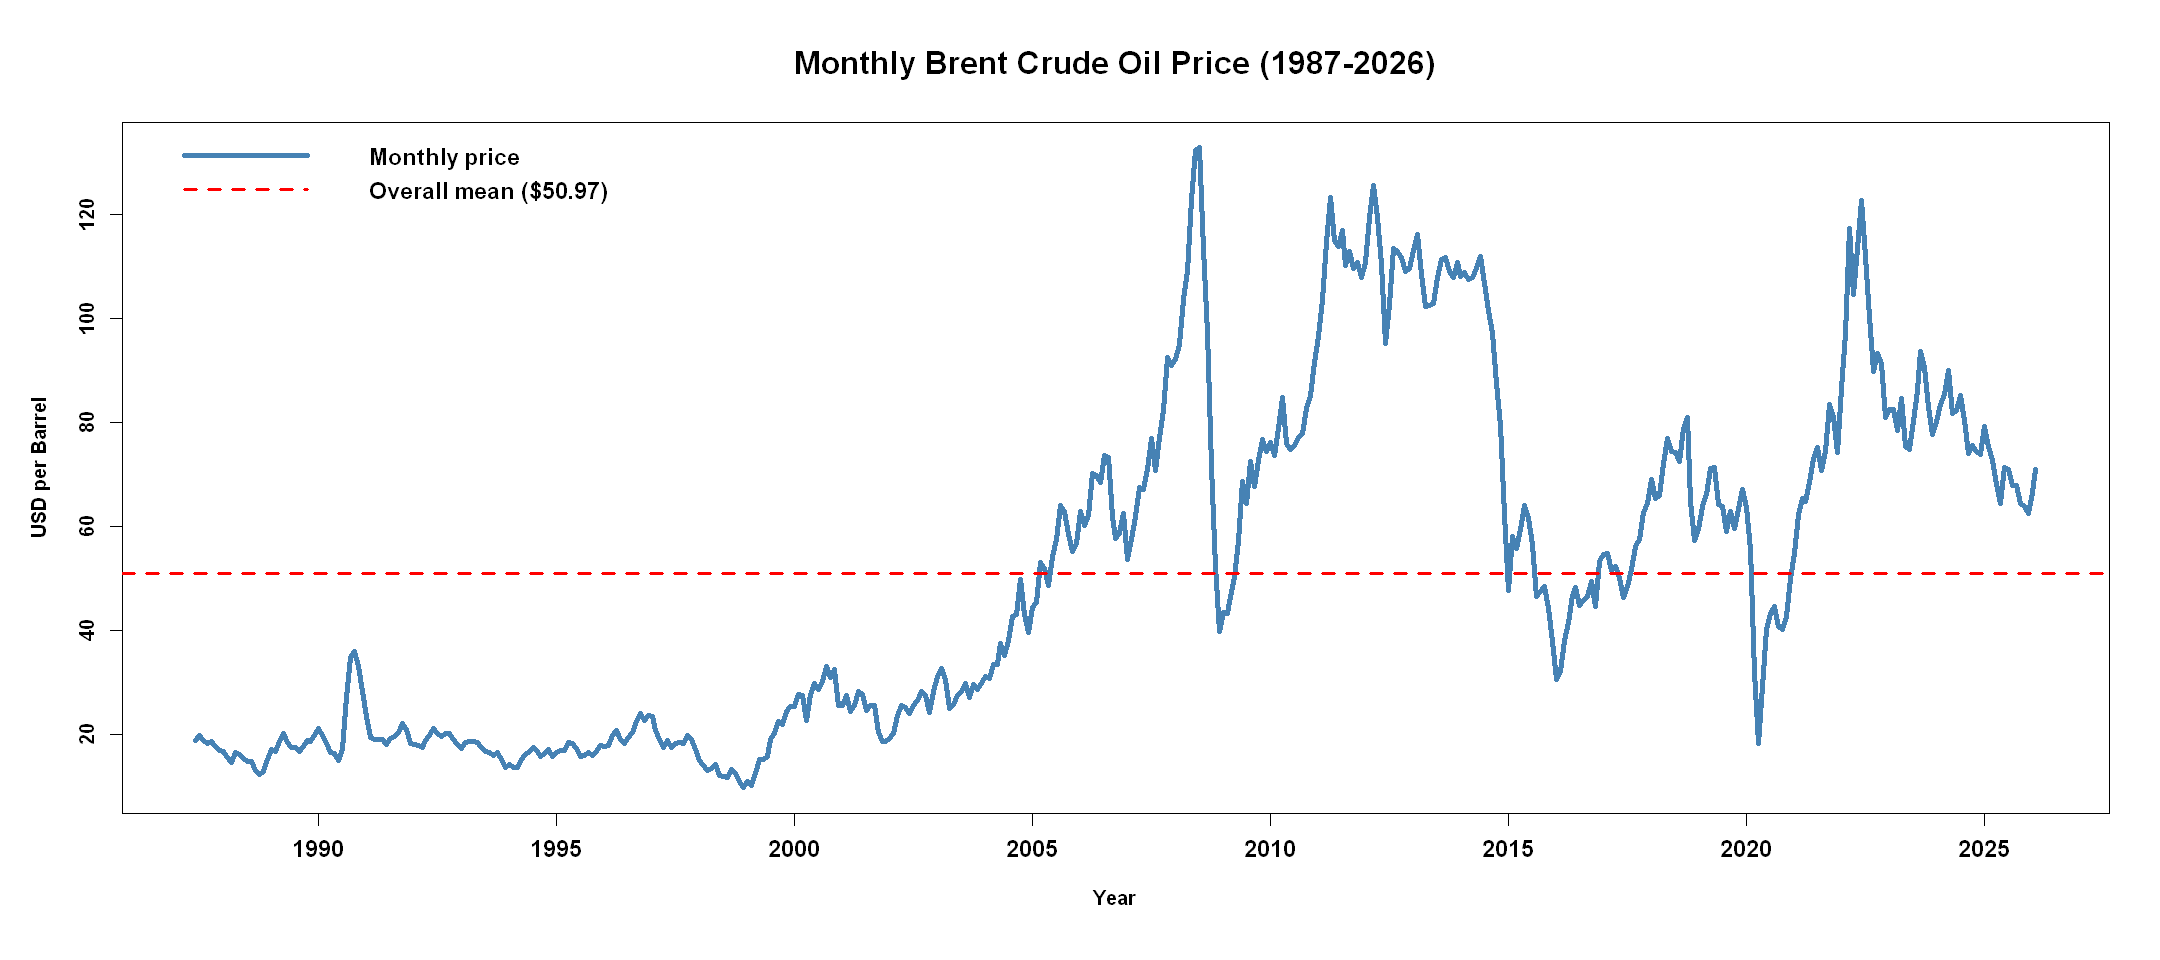

In [91]:

par(bg = "white", mar = c(6, 5, 5, 2) + 0.1, font.lab = 2, font.axis = 2, font.main = 2)

# Data helpers
ticks <- seq(1990, 2025, 5)
m_price <- mean(oil_ts)

# Plotting with grouped arguments
plot(oil_ts, col = "steelblue", lwd = 4, xaxt = "n",
     main = "Monthly Brent Crude Oil Price (1987-2026)",
     xlab = "Year", ylab = "USD per Barrel",cex.main = 1.6, cex.lab = 1.35)

# Add layers
axis(1, at = ticks, labels = ticks, cex.axis = 1.2)
abline(h = m_price, col = "red", lty = 2, lwd = 3)

legend("topleft", bty = "n", cex = 1.15, text.font = 2,
       legend = c("Monthly price", paste0("Overall mean ($", round(m_price, 2), ")")),col = c("steelblue", "red"), lty = 1:2, lwd = 4:3)

<span style="color: #1b8a3a;"><strong>Interpretation of the raw series plot:</strong></span>
The plot shows the monthly Brent Crude Oil price series over the 
full sample period.

**Trend:** The series exhibits both upward and downward trends across 
the sample period, driven by major economic events such as the 2008 
financial crisis and the 2020 COVID-19 crash, meaning the mean is 
not constant over time.

**Variance:** Price fluctuations are noticeably larger in the second 
half of the sample than in the first, suggesting that the variance 
grows with the price level.

**Autocorrelation:** Consecutive monthly prices move together 
smoothly, indicating strong positive autocorrelation and a high 
degree of persistence in the series.

Overall, the series does not appear to be stationary. Two issues must be addressed before modeling: the non-constant variance and the non-constant mean
<br>
<br>



<h3 style="font-weight:800;">2.3  Train/Test Split</h3>
Before any statistical analysis begins, the dataset is split into a 
training set and a test set.

- A 90/10 split is applied, withholding the last 46 observations 
(May 2022 – February 2026) as the test set. 
- The 90/10 split was chosen instead of the conventional 95/5 split because it provides a larger and more reliable test window (46 observations instead of 23) and ensures that the test period includes the 2022 Ukraine war oil price spike and the subsequent correction, allowing the model to be evaluated under significant market volatility rather than a stable period.

In [7]:
# ── Train/Test Split (90/10) ──────────────────────────────────
# Calculate split point
n_total <- length(oil_ts)
n_test  <- round(n_total * 0.10)
n_train <- n_total - n_test

cat("Total observations   :", n_total, "\n")
cat("Training observations:", n_train, "\n")
cat("Test observations    :", n_test,  "\n")

# ── Create train and test sets using index ────────────────────
train_ts <- head(oil_ts, n_train)
test_ts  <- tail(oil_ts, n_test)

# ── Confirm periods ───────────────────────────────────────────
cat("Training period      :", start(train_ts),
                        "to", end(train_ts),  "\n")
cat("Test period          :", start(test_ts),
                        "to", end(test_ts),   "\n")

Total observations   : 465 
Training observations: 419 
Test observations    : 46 
Training period      : 1987 6 to 2022 4 
Test period          : 2022 5 to 2026 2 



<h3 style="font-weight:800;">2.4 Variance Stabilization</h3>

The visual inspection of the raw series suggested that the **variance 
is not constant** , price fluctuations grow larger as the price level 
increases. To formally verify this and determine the appropriate 
transformation, a Box-Cox analysis is applied to the training set.

The Box-Cox family of transformations is defined as:

$$T(Y_t) = \begin{cases} \frac{Y_t^\lambda - 1}{\lambda} & \lambda \neq 0 \\ \ln(Y_t) & \lambda = 0 \end{cases}$$

The optimal λ is selected by maximizing the log-likelihood over a 
range of candidate values. A value of λ = 1 indicates that no 
transformation is needed. A value of λ = 0 corresponds to a log 
transformation, which is the most common choice for financial and 
commodity price series. If the optimal λ is significantly different 
from 1, a transformation is required to stabilize the variance 
before modeling.

In [8]:
#  Box-Cox lambda search on training set 
lambda_result <- BoxCox.lambda(train_ts,
                               method = "loglik",
                               lower  = -2,
                               upper  =  2)

cat("Optimal lambda:", round(lambda_result, 4), "\n")

# Interpretation 
if (abs(lambda_result - 1) < 0.1) {
  cat("Lambda is close to 1 — no transformation needed.\n")
} else if (abs(lambda_result) < 0.1) {
  cat("Lambda is close to 0 — log transformation recommended.\n")
} else {
  cat("Lambda =", round(lambda_result, 4),
      ", Box-Cox transformation recommended.\n")
}

Optimal lambda: -0.3 
Lambda = -0.3 , Box-Cox transformation recommended.


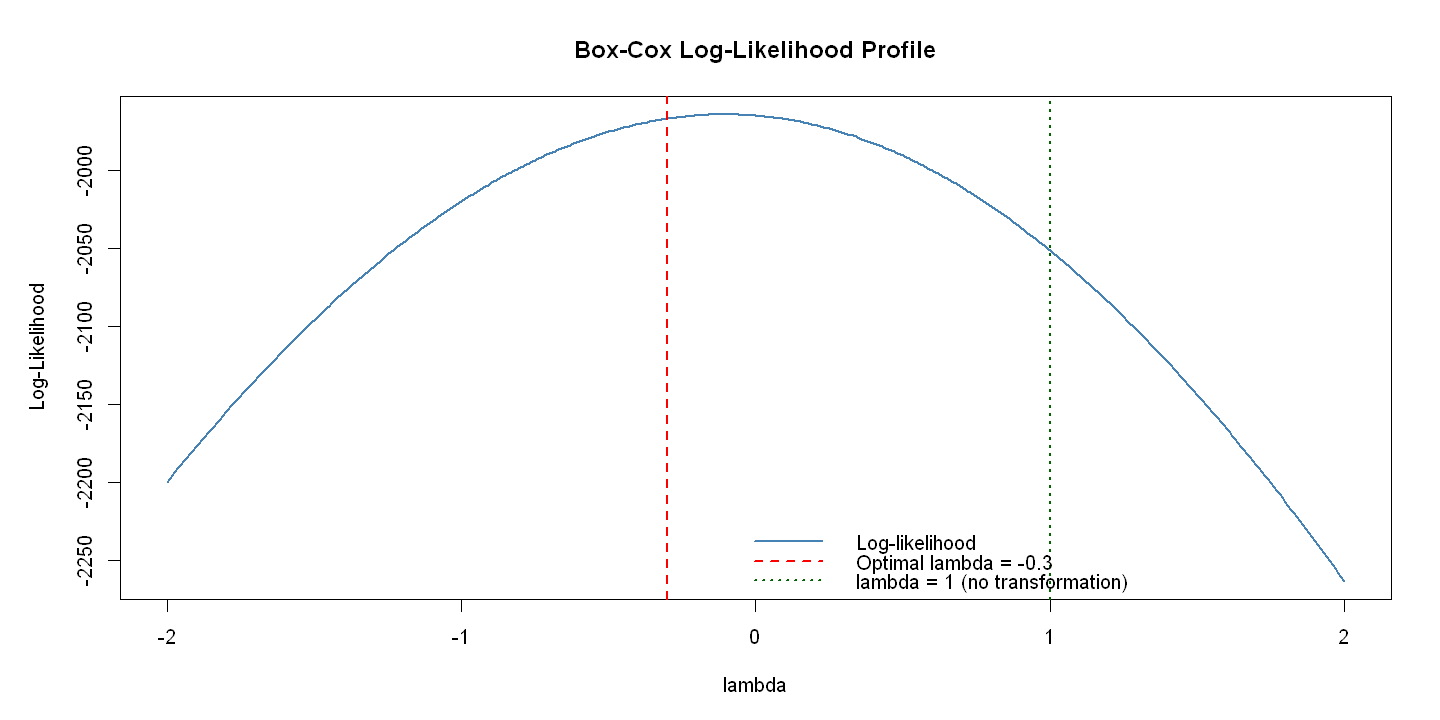

In [ ]:
# Plot Box-Cox log-likelihood profile (using lambda_result from previous cell)

lambda_seq <- seq(-2, 2, by = 0.01)
ll_vals <- sapply(lambda_seq, function(l) {
  tryCatch({
    z <- BoxCox(train_ts, lambda = l)
    sum(dnorm(z, mean = mean(z), sd = sd(z), log = TRUE) + (l - 1) * log(train_ts))
  }, error = function(e) NA_real_)
})

par(bg = "white", mar = c(5, 5, 4, 2))

plot(lambda_seq, ll_vals,
     type = "l", col = "steelblue", lwd = 2,main = "Box-Cox Log-Likelihood Profile",xlab = "lambda", ylab = "Log-Likelihood")

abline(v = lambda_result, col = "red", lty = 2, lwd = 2)
abline(v = 1, col = "darkgreen", lty = 3, lwd = 2)

legend("bottomright",
       legend = c("Log-likelihood",paste0("Optimal lambda = ", round(lambda_result, 4)),
                  "lambda = 1 (no transformation)"), col = c("steelblue", "red", "darkgreen"),
                   lty = c(1, 2, 3),lwd = c(2, 2, 2),bty = "n")

<span style="color: #1b8a3a;"><strong>Interpretation : </strong></span>
The Box-Cox analysis returns an optimal λ = -0.3, which is 
significantly different from 1. This confirms that the variance 
of the training series is not constant and a transformation is 
required before modeling.

Since λ = -0.3 is close to 0, it suggests that a log-like 
transformation is appropriate. The log-likelihood profile plot 
shows a clear peak at λ = -0.3, well away from λ = 1 (green 
dotted line), which would correspond to no transformation. 
The Box-Cox transformation with λ = -0.3 is therefore applied 
to the training set to stabilize the variance.

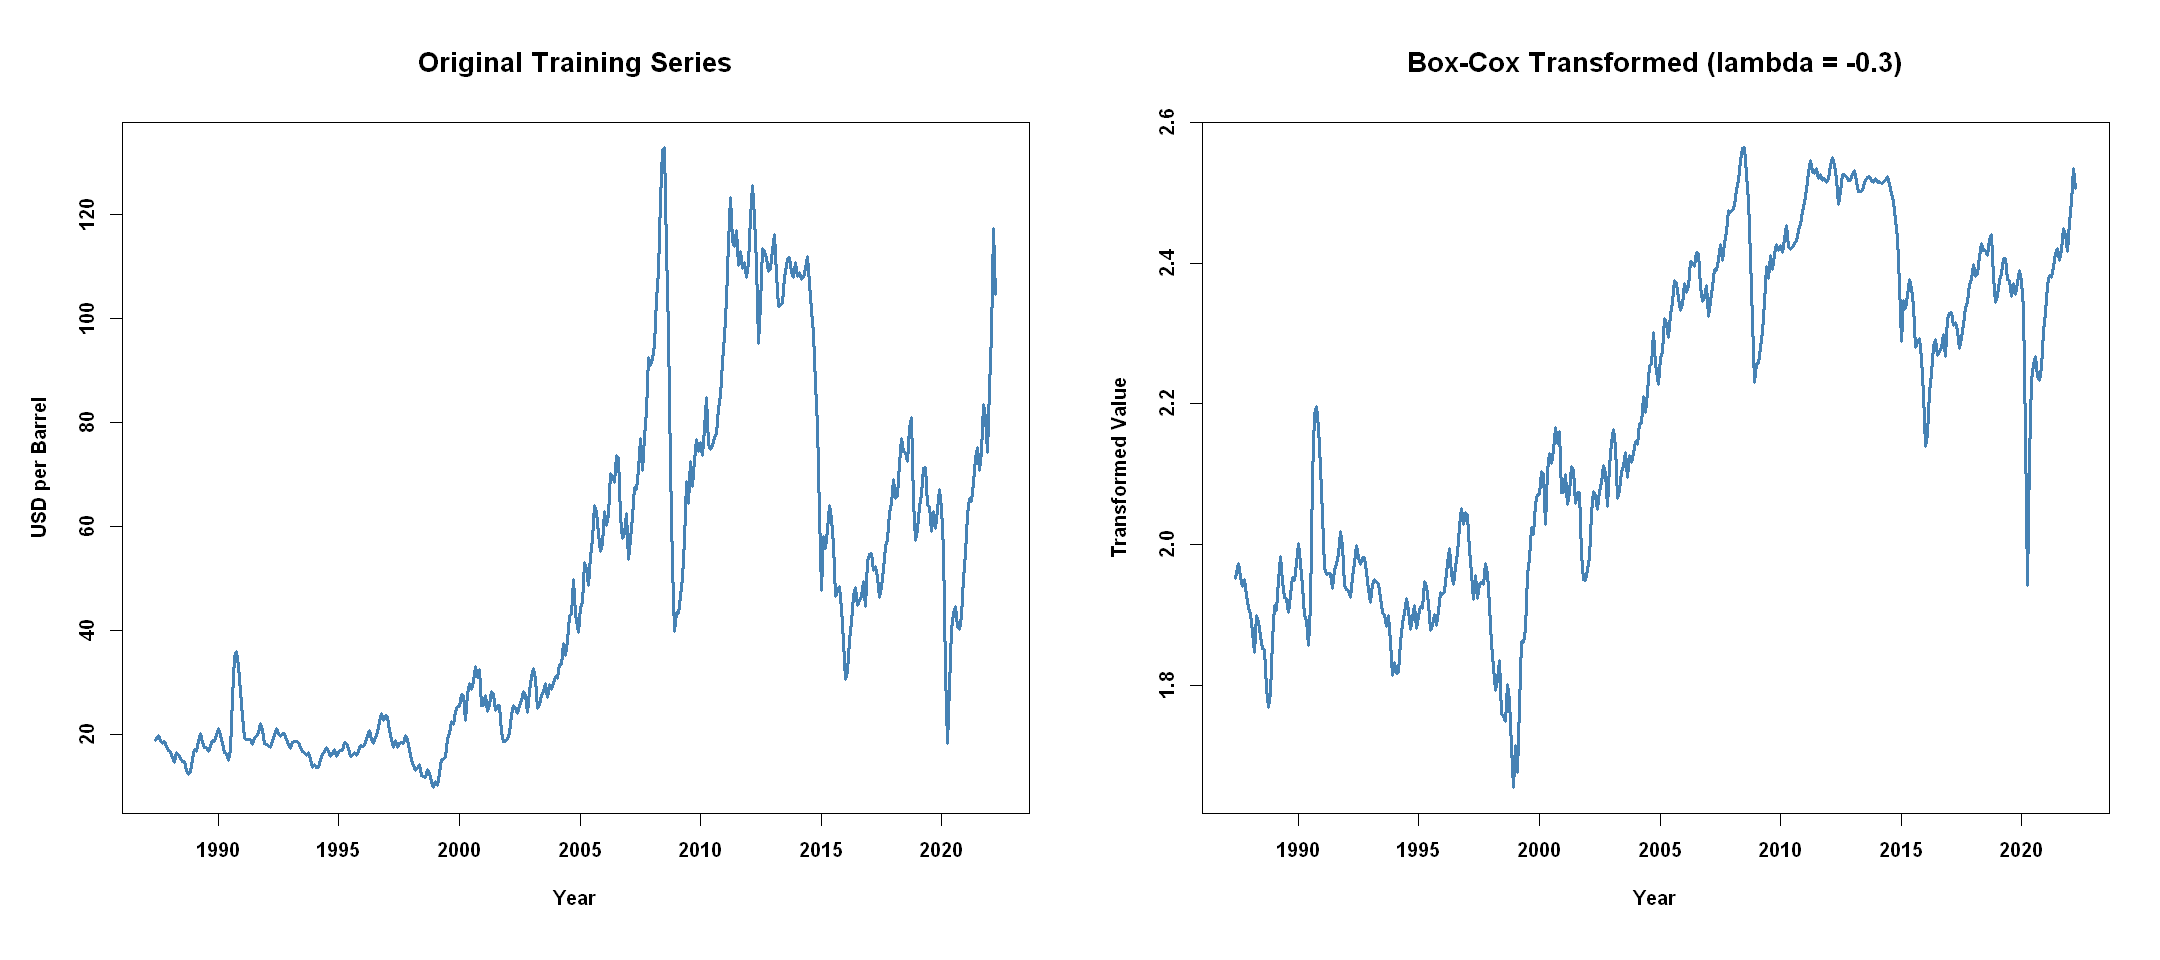

In [ ]:
# Apply Box-Cox transformation to training set
train_bc <- BoxCox(train_ts, lambda = lambda_result)


par(mfrow = c(1, 2),bg = "white",mar = c(6, 5, 5, 2) + 0.1,font.lab = 2,font.axis = 2)

# Original series
plot(train_ts,
     main = "Original Training Series",
     ylab = "USD per Barrel",xlab = "Year",
     col  = "steelblue",lwd  = 3,cex.main = 1.35,cex.lab = 1.2,font.main = 2)

# Transformed series (ASCII text to avoid Windows encoding warning)
plot(train_bc,
     main = paste0("Box-Cox Transformed (lambda = ",
                   round(lambda_result, 4), ")"),
     ylab = "Transformed Value",xlab = "Year",
     col  = "steelblue",lwd  = 3,cex.main = 1.35,cex.lab = 1.2,font.main = 2)

par(mfrow = c(1, 1))

<span style="color: #1b8a3a;"><strong>Interpretation : </strong></span>
Comparing the two plots, the effect of the Box-Cox transformation with λ = −0.3 is evident. In the original series, the amplitude of fluctuations increases with the level of the series: the swings during the 2005–2015 period are considerably larger than those observed between 1987 and 2000. After applying the transformation, the fluctuations appear more uniform over the entire time span, suggesting that the variance has been stabilized.

However, the transformed series still displays a clear upward trend, indicating that the mean of the process may not be constant over time. To formally assess stationarity, the Augmented Dickey–Fuller test is applied to the transformed series.

In [149]:
# ADF test on Box-Cox transformed training series 
adf_bc <- adf.test(train_bc)
print(adf_bc)



	Augmented Dickey-Fuller Test

data:  train_bc
Dickey-Fuller = -2.4529, Lag order = 7, p-value = 0.3861
alternative hypothesis: stationary



**ADF Test Result**
The Augmented Dickey-Fuller test on the Box-Cox transformed series gives a test statistic of -2.4529 and a p-value of 0.3861.

Because this p-value is much larger than 0.05, we fail to 
reject the null hypothesis of a unit root. This confirms that the 
transformed series is not stationary , the mean is still not 
constant over time and a trend remains present.

Differencing is therefore required to achieve stationarity.
Therefore, differencing is needed before fitting ARIMA models.
<br>
<br>


<h3 style="font-weight:800;">2.5 Stationarity and Differencing</h3>
The ADF test confirmed that the Box-Cox transformed series is not 
stationary. The trend must be removed before any ARIMA model can 
be applied.

Although several techniques exist for removing trend , such as 
regression detrending and moving average smoothing , differencing 
is the most commonly used method in ARIMA modeling because it 
directly produces the integrated component of the model and does 
not require assuming a specific functional form for the trend.

First-order differencing is applied to the transformed training 
series. The resulting series is then plotted and tested formally 
using the ADF test to confirm that stationarity has been achieved.

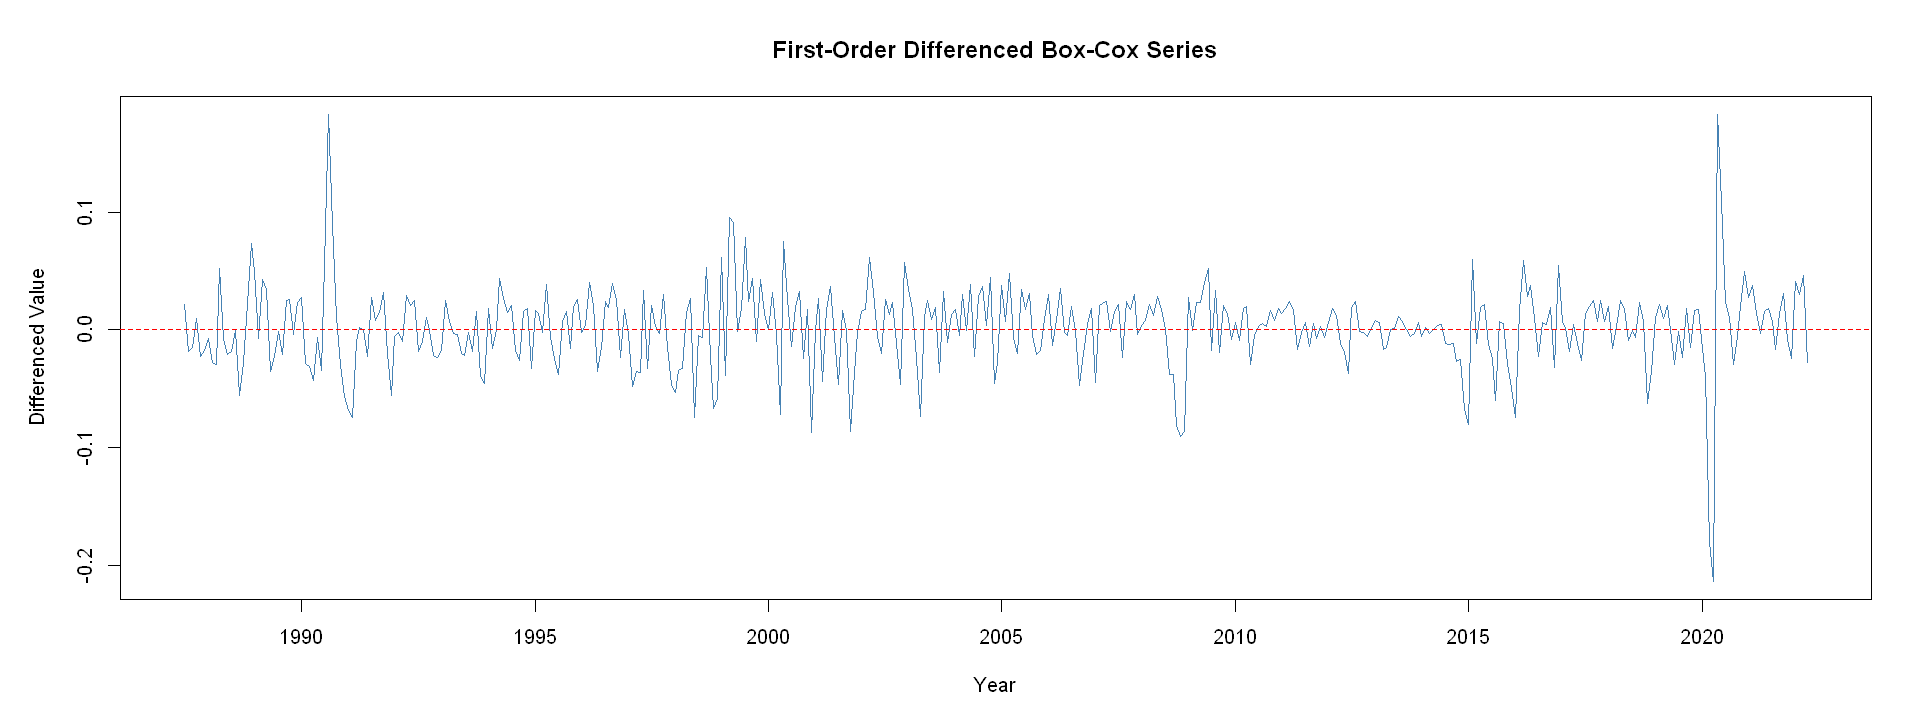

In [94]:
# First order differencing on transformed series 
train_diff <- diff(train_bc, lag = 1)

par(bg  = "white",mar = c(5, 5, 4, 2))

plot(train_diff,
     main = "First-Order Differenced Box-Cox Series",ylab = "Differenced Value",
     xlab = "Year",col  = "steelblue",lwd  = 1.5)

abline(h   = 0,col = "red",lty = 2,lwd = 1.5)

In [13]:
# ADF test on differenced transformed series
adf_diff <- adf.test(train_diff)
print(adf_diff)

Warning message in adf.test(train_diff):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  train_diff
Dickey-Fuller = -8.0772, Lag order = 7, p-value = 0.01
alternative hypothesis: stationary



<span style="color: #1b8a3a;"><strong>Interpretation :  </strong></span>The plot of the first-order differenced Box-Cox series shows that 
the series now fluctuates around zero with no visible trend. The 
mean appears constant across the full sample period, which is a 
first visual indication that stationarity has been achieved. Two 
isolated spikes are visible around 1991 and 2020  corresponding 
to the Gulf War and the COVID-19 demand collapse respectively. These 
are extreme but isolated events and do not reflect a systematic 
pattern in the series.

<span style="color: #1b8a3a;"><strong>Augmented Dickey-Fuller (ADF) Test Results</strong></span>
- The ADF test returns a test statistic of **-8.0772** and a 
**p-value = 0.01**. The warning message indicates that the real 
p-value is even smaller than 0.01.
- Since the **p-value < 0.05**, we **reject H₀** (unit root), 
confirming that the differenced series is **stationary**.
- One order of differencing was sufficient to achieve stationarity, 
meaning the integrated order of the model is **d = 1**.
- Since differencing has successfully made the series stationary, 
an  <span style="color: #c62828;"><strong>ARIMA(p, 1, q)</strong></span> model is appropriate.
- The orders **p** (AR component) and **q** (MA component) will 
be determined in the following subsection using the ACF and PACF 
plots.

<br>
<br>



<h3 style="font-weight:800;">2.6 ACF and PACF Analysis</h3>

Now that the series is stationary, the Autocorrelation Function 
(ACF) and Partial Autocorrelation Function (PACF) are examined 
to identify the orders p and q of the ARIMA(p, 1, q) model.

The ACF measures the correlation between the series and its lagged 
values. The PACF measures the same correlation but after removing 
the effect of intermediate lags. Together they provide the 
following guidance:

- If the **ACF cuts off** after lag q and the **PACF tails off** 
→ suggests an **MA(q)** process
- If the **PACF cuts off** after lag p and the **ACF tails off** 
→ suggests an **AR(p)** process
- If **both tail off** → suggests an **ARMA(p, q)** process

Any spike that crosses the blue dashed confidence bands is 
considered statistically significant.

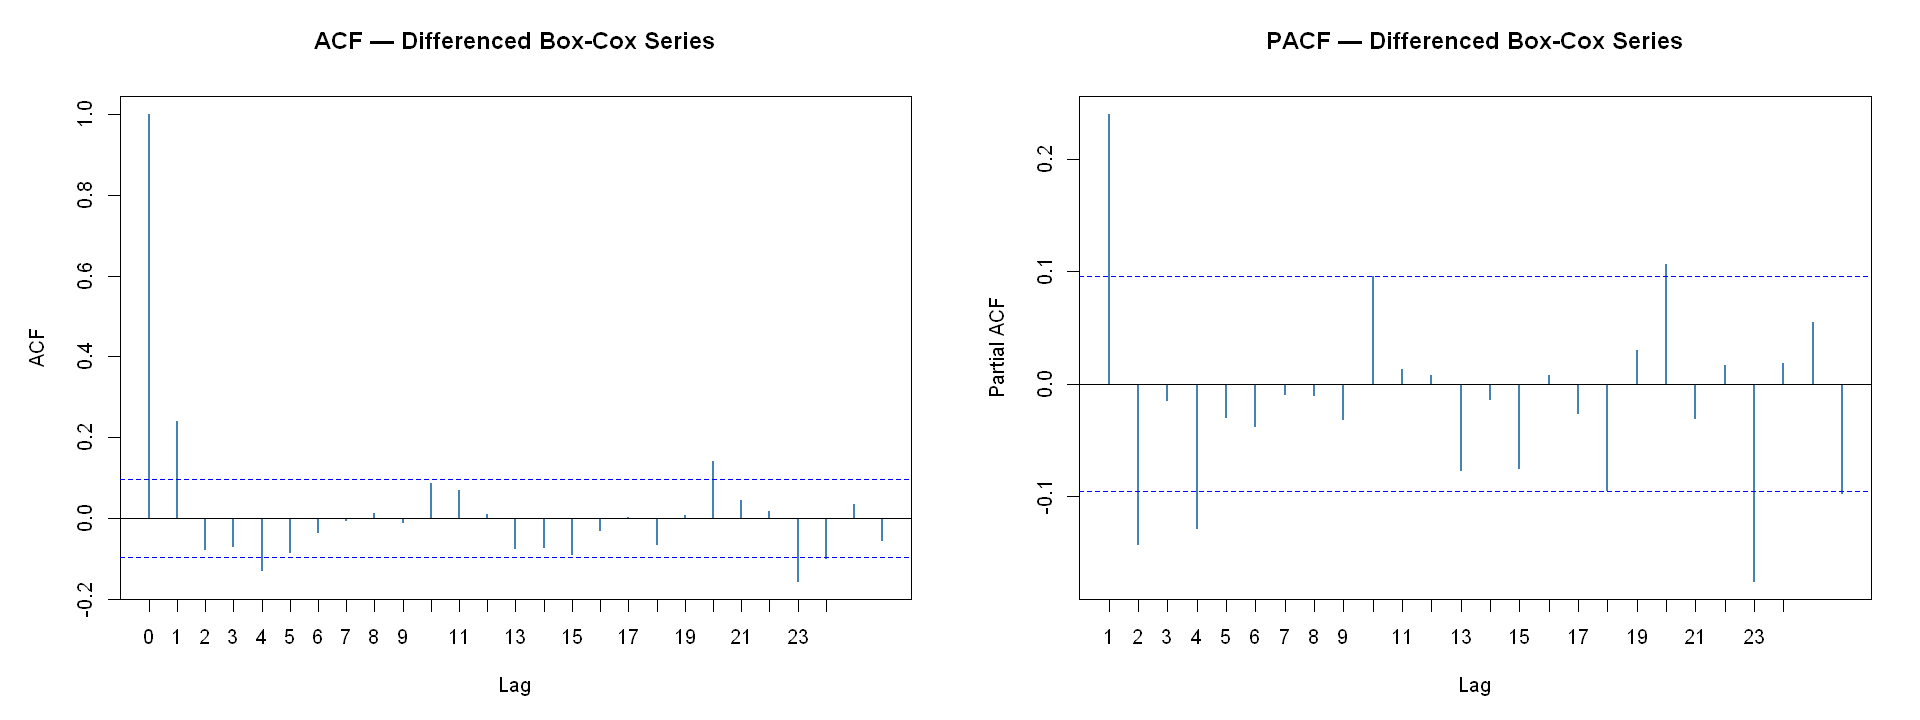

In [101]:
# ACF and PACF — lags displayed in months 

par(mfrow = c(1, 2),bg    = "white",mar   = c(5, 5, 4, 2))

# ACF
acf(train_diff,main    = "ACF — Differenced Box-Cox Series",
    col     = "steelblue",lwd     = 2,xaxt    = "n")
axis(1,at     = 0:24 / 12,labels = 0:24)

# PACF
pacf(train_diff,main    = "PACF — Differenced Box-Cox Series",
     col     = "steelblue",lwd     = 2,xaxt    = "n")
axis(1,at     = 1:24 / 12,labels = 1:24)

par(mfrow = c(1, 1))

<span style="color: #1b8a3a;"><strong>Interpretation of the ACF and PACF : </strong></span>

**ACF:** One significant spike is observed at lag 1, after which 
the values fall within the confidence bands. A few isolated spikes 
appear at higher lags and some are still significant, but they follow no 
regular pattern. These higher-lag spikes may be linked to crisis-driven 
outliers (especially the 2008 financial crisis and the 2020 COVID-19 shock) 
rather than a stable autocorrelation structure. The overall pattern still 
suggests a cut-off after lag 1, characteristic of an MA(1) process.

**PACF:** Significant spikes are observed at lags 1 and 2, after 
which the values tail off gradually toward zero. This tailing-off 
pattern is characteristic of an Autoregressive process.

Based on the ACF and PACF patterns, the following candidate models 
are identified for the ARIMA(p, 1, q) framework:

| Model | AR order (p) | d | MA order (q) | Justification |
|---|---|---|---|---|
| ARIMA(0,1,1) | 0 | 1 | 1 | ACF cuts off at lag 1, PACF tails off |
| ARIMA(1,1,1) | 1 | 1 | 1 | Both ACF and PACF show lag 1 significance |
| ARIMA(2,1,1) | 2 | 1 | 1 | PACF significant at lags 1 and 2, ACF cuts at lag 1 |
| ARIMA(1,1,0) | 1 | 1 | 0 | PACF cuts off at lag 1 as an alternative |
| ARIMA(2,1,0) | 2 | 1 | 0 | PACF significant at lags 1 and 2 |

These candidates are preliminary. In the next step, we first use the **BIC and AIC subset chart** to refine and update the candidate set, then we fit and compare the final candidates using AIC and BIC to select the best fitting model.


Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
"8  linear dependencies found"


Reordering variables and trying again:


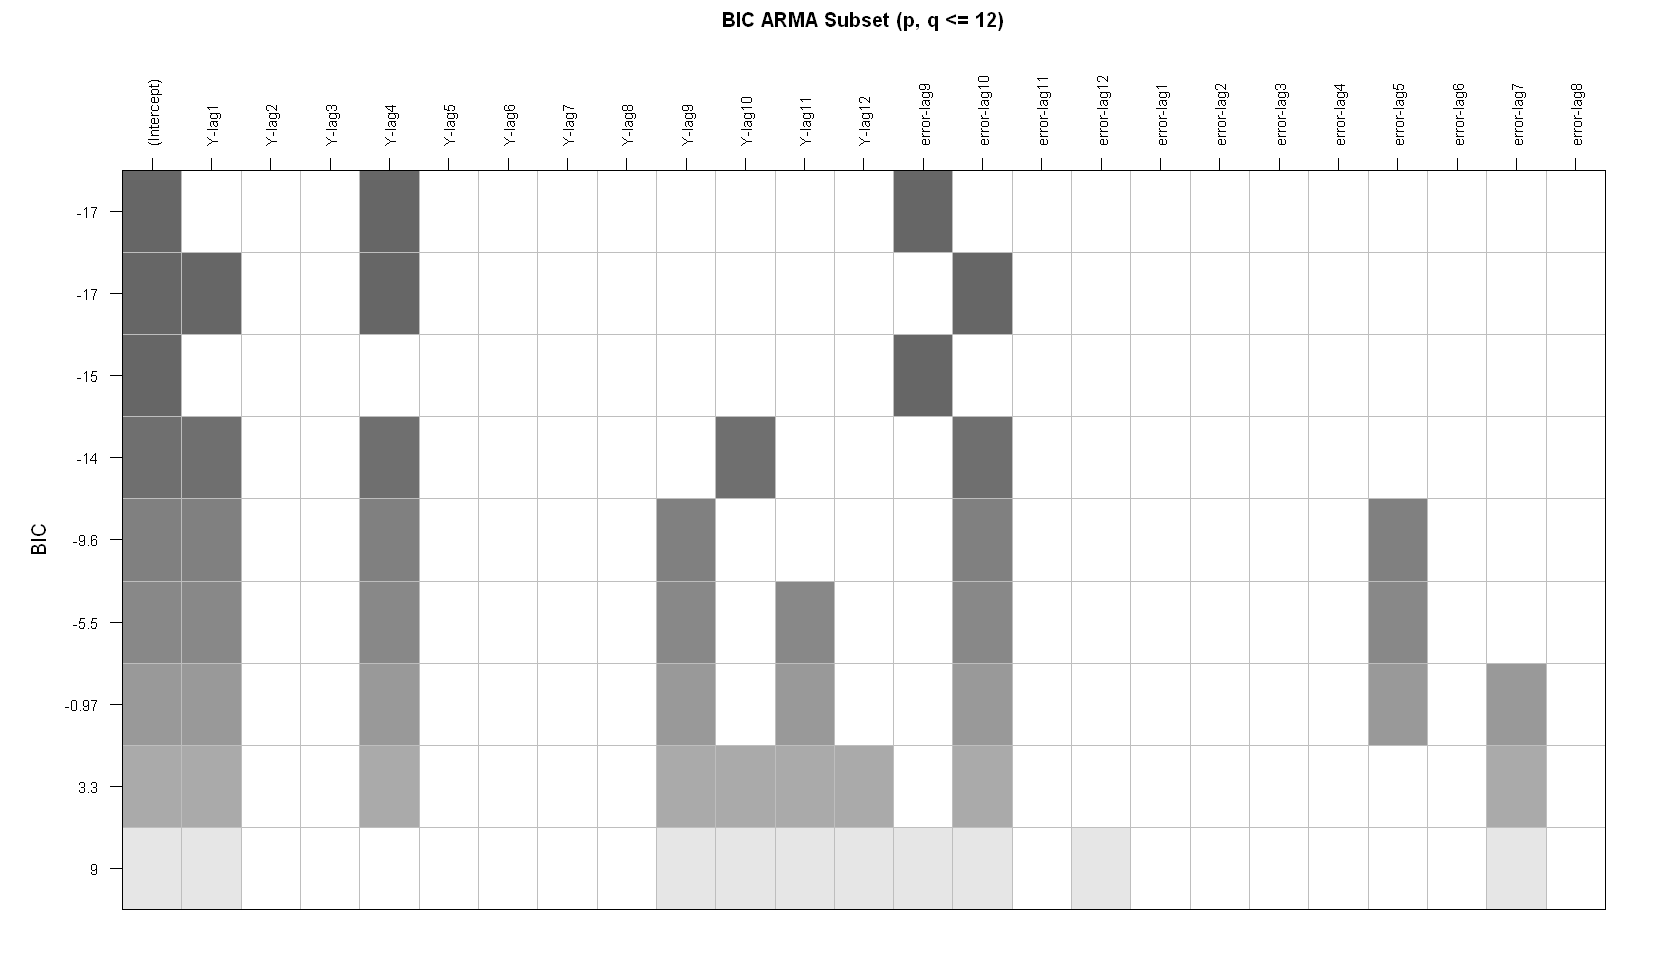

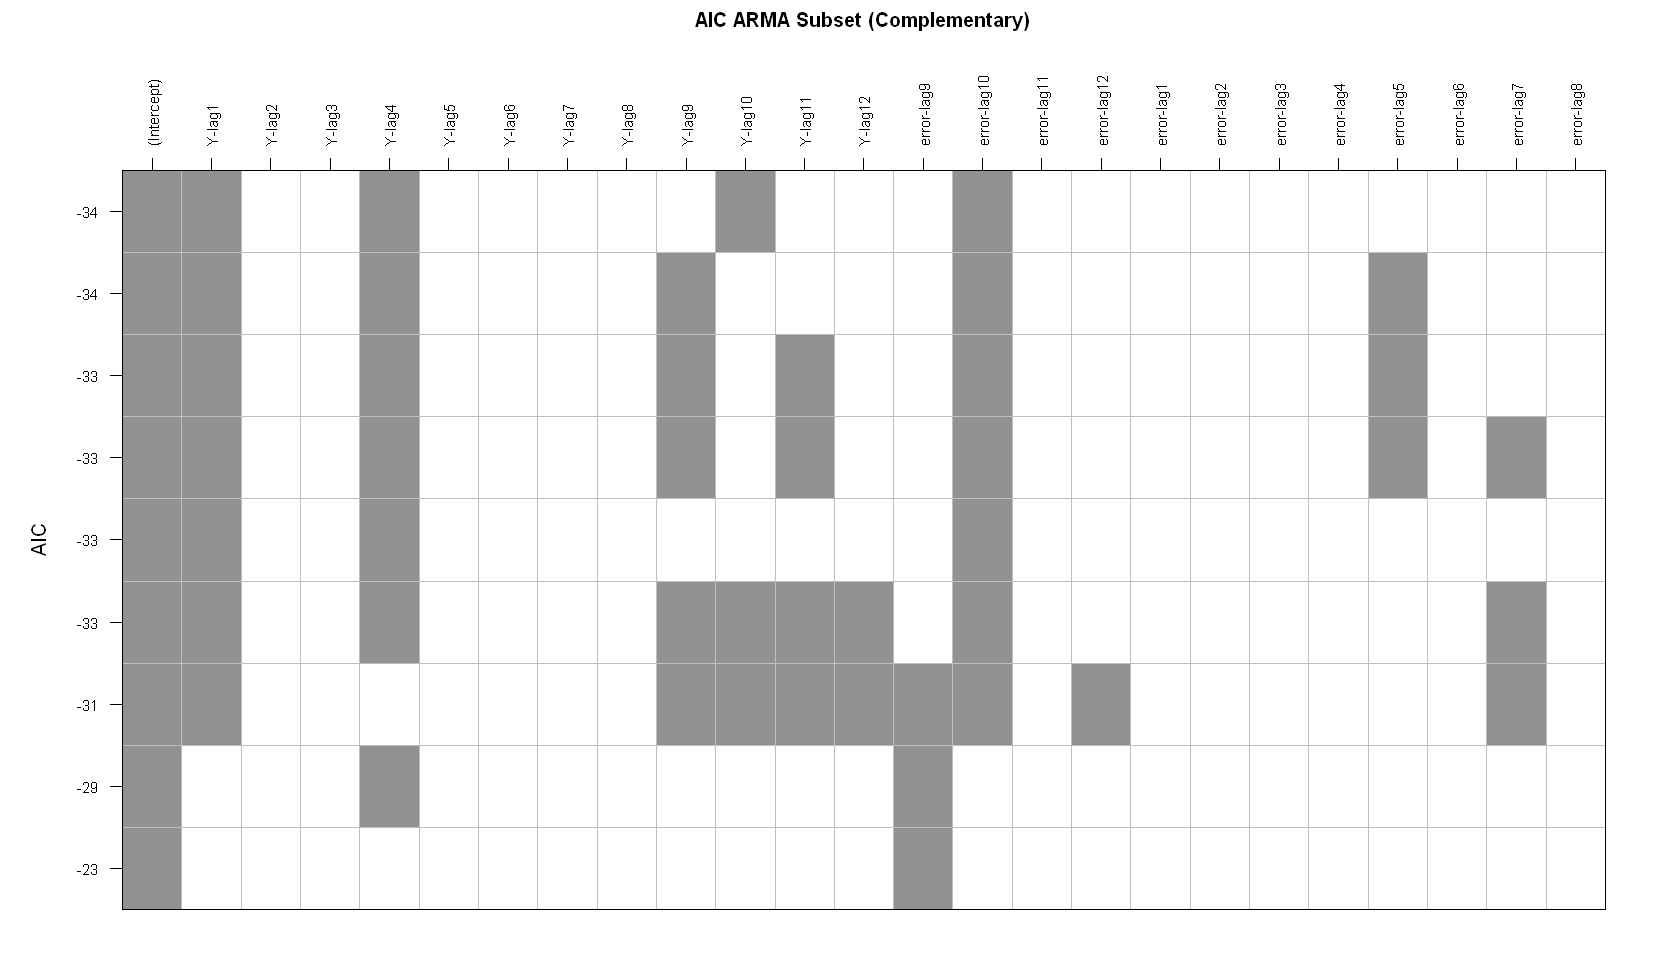

In [145]:
# ARMA subset selection
x <- na.omit(as.numeric(train_diff))

max_order <- 12
show_aic <- TRUE

subset_models <- TSA::armasubsets(
  y = x,
  nar = max_order,
  nma = max_order,
  ar.method = "ols"
 )

# Plot settings: keep text readable and avoid title/label overlap
options(repr.plot.width = 14, repr.plot.height = 8)

# BIC plot (primary)
par(bg = "white", mar = c(6, 5, 9, 2) + 0.1, cex.axis = 0.75)
plot(subset_models, scale = "BIC", main = "")
title(main = "BIC ARMA Subset (p, q <= 12)", line = 6, cex.main = 1.0)

# AIC plot (complementary)
if (show_aic) {
  par(bg = "white", mar = c(6, 5, 9, 2) + 0.1, cex.axis = 0.75)
  plot(subset_models, scale = "AIC", main = "")
  title(main = "AIC ARMA Subset (Complementary)", line = 6, cex.main = 1.0)
}

<span style="color: #1b8a3a;"><strong>Interpretation: ARMA Subset Selection (AIC and BIC)</strong></span>.

As a complement to the ACF/PACF analysis, ARMA subset selection plots
were produced using both AIC and BIC. Each row represents a candidate
model ranked by its criterion value where rows near the top correspond to
better-fitting models after penalizing for complexity. Dark squares
indicate which lags are included in each model.

**What we observe:**
- Both charts consistently highlight **Y-lag 1** and **Y-lag 4** among
the AR components, and **error-lag 9** and **error-lag 10** among the
MA components. 

- However, The armasubsets()  function returned a warning of linear dependencies 
among the lagged regressors, indicating that the results are 
unreliable for this series. This is consistent with the high 
persistence and volatility clustering known to affect commodity 
price data. The candidate models are therefore identified 
exclusively from the ACF and PACF analysis in the previous 
subsection.


**AIC vs BIC role:**
- **BIC** is stricter and favors simpler models.
- **AIC** is less strict and may keep slightly richer models.
- Both criteria are used as a cross-check,
but the final candidate models are those identified through the
standard ACF/PACF reading presented above, as this approach is
directly aligned with the ARIMA methodology applied in this study


**Justification of max_order = 12 (context):** the data are monthly, so 12 lags correspond to one full year. Searching up to 12 lets us check annual-lag effects while still controlling model complexity through AIC/BIC penalties.


**Conclusion**
The five candidate models identified above will now be fitted on the
training set. As an additional robustness check, the model identification
procedure is repeated on a restricted time window (2009–2018).
This window is chosen to exclude the major crisis periods of **2008** (global financial crisis)
and **2020** (COVID-19 pandemic), so we can evaluate model identification on a more stable
sub-period and verify whether similar candidate models emerge independently.
<br>
<br>



<h3 style="font-weight:800;">2.7 Model Identification on a Restricted Time Window</h3>

The full training series spans 1987 to 2022 and contains two extreme
price shocks ,the 2008 global financial crisis and the 2020 COVID-19
demand collapse. As discussed, these events distort the ACF and PACF
at higher lags, making it harder to isolate the true underlying
autocorrelation structure of the series.

To address this, the model identification procedure is repeated on a
restricted sub-period covering **January 2009 to December 2018**. This
window was chosen because it represents a relatively stable phase of
the oil price cycle following the recovery from the 2008 crash and
ending before the COVID-19 disruption, while still containing
sufficient observations (120 months) for reliable ACF and PACF analysis.

The same transformation pipeline is applied to this sub-series: Box-Cox
transformation with the same λ = -0.3, followed by first-order
differencing. Stationarity is then confirmed via ADF test, and the ACF
and PACF are examined to identify candidate models. The resulting
candidates are compared to those obtained from the full training series
to assess the robustness of the identification.

Window observations: 120 
Window start       : 2009 1 
Window end         : 2018 12 


Window observations: 120 
Window start       : 2009 1 
Window end         : 2018 12 


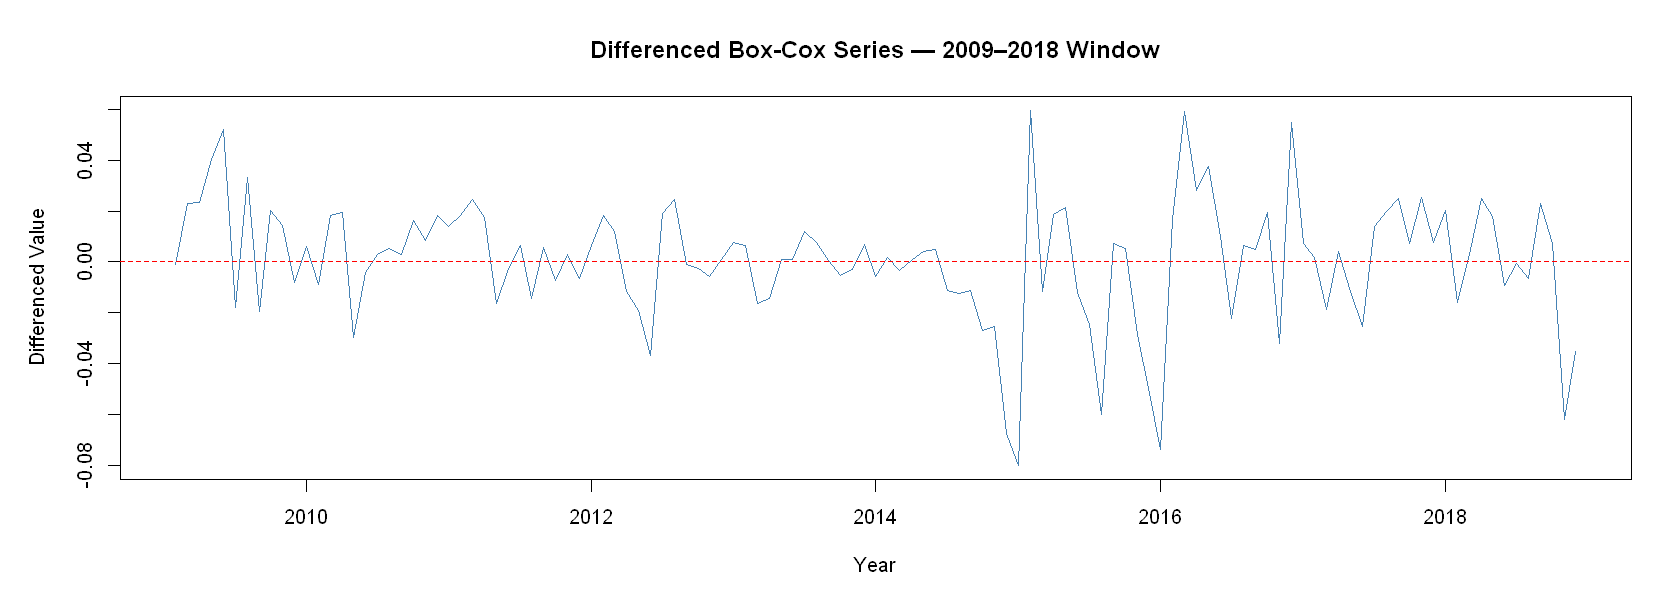

In [126]:
# Extract restricted time window: 2009–2018
window_ts <- window(train_ts,
                    start = c(2009, 1),
                    end   = c(2018, 12))

cat("Window observations:", length(window_ts), "\n")
cat("Window start       :", start(window_ts),  "\n")
cat("Window end         :", end(window_ts),     "\n")

# Apply same Box-Cox transformation (λ = -0.3) 
window_bc <- BoxCox(window_ts, lambda = lambda_result)

# Apply first-order differencing 
window_diff <- diff(window_bc, lag = 1)

# Plot the differenced window series 
options(repr.plot.width = 14, repr.plot.height = 5)

par(bg  = "white",
    mar = c(5, 5, 4, 2))

plot(window_diff,
     main = "Differenced Box-Cox Series — 2009–2018 Window",
     ylab = "Differenced Value",xlab = "Year",
     col  = "steelblue",lwd  = 1.5)

abline(h   = 0,col = "red",
       lty = 2,lwd = 1.5)

In [127]:
# ADF test on differenced window series 
adf_window <- adf.test(window_diff)
print(adf_window)

Warning message in adf.test(window_diff):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  window_diff
Dickey-Fuller = -4.5118, Lag order = 4, p-value = 0.01
alternative hypothesis: stationary



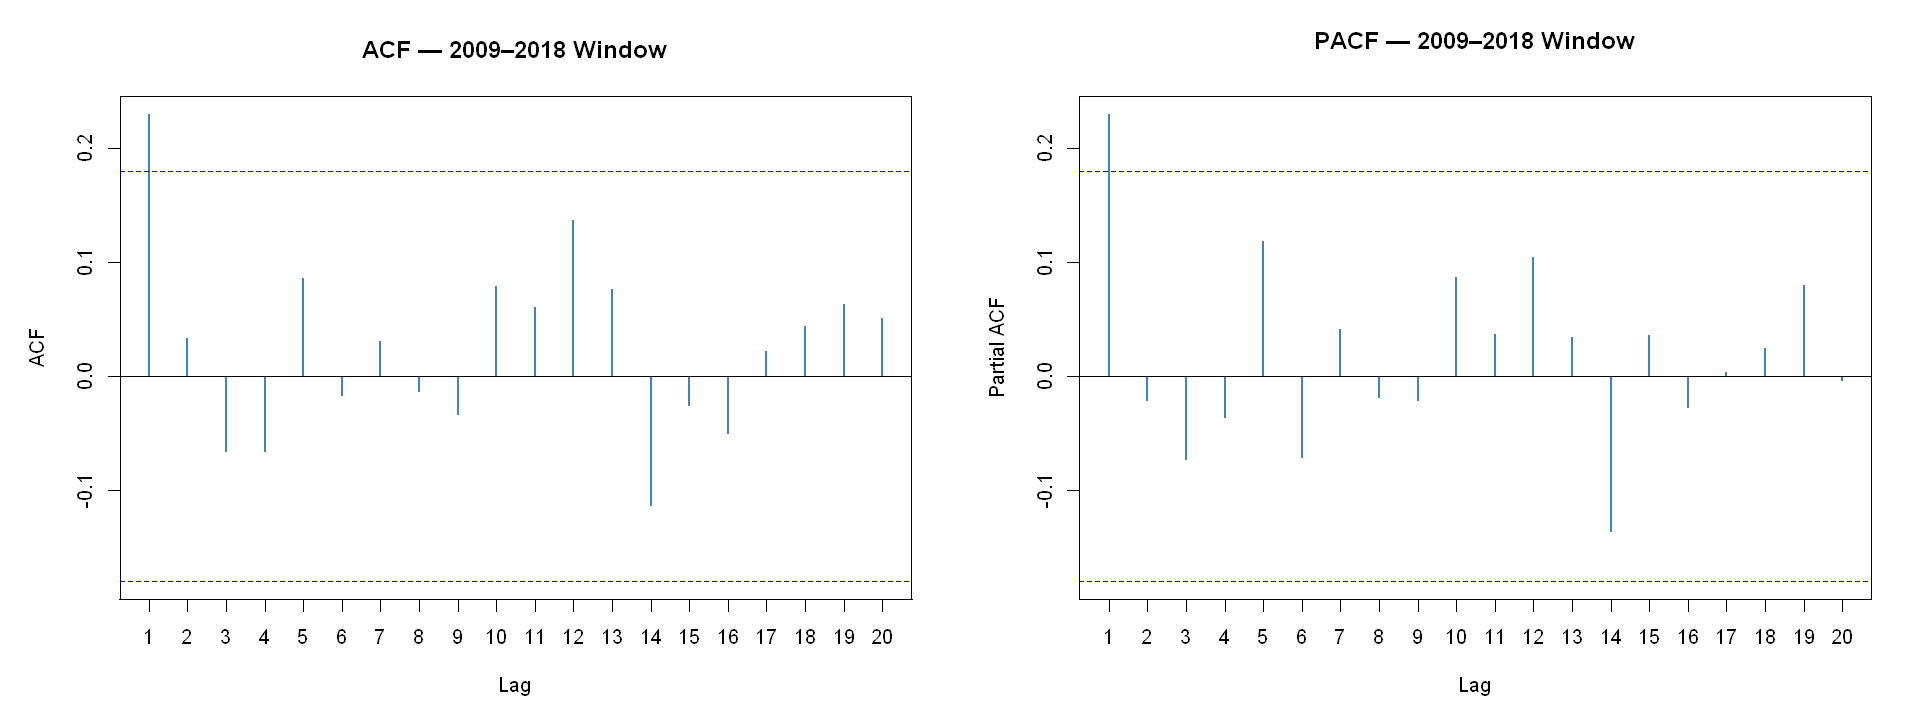

In [129]:
# ACF and PACF of differenced window series 
options(repr.plot.width = 16, repr.plot.height = 6)

par(mfrow = c(1, 2),bg    = "white",mar   = c(5, 5, 4, 2))

acf(window_diff,
    main    = "ACF — 2009–2018 Window",
    col     = "steelblue",lwd     = 2,xaxt    = "n")
axis(1,at     = 0:24 / 12,labels = 0:24)

pacf(window_diff,
     main    = "PACF — 2009–2018 Window",col     = "steelblue",
     lwd     = 2,xaxt    = "n")
axis(1,at     = 1:24 / 12,labels = 1:24)

par(mfrow = c(1, 1))


<span style="color: #1b8a3a;"><strong>Interpretation — 2009–2018 Window</strong></span>.


**ACF:** A significant spike is observed at lag 1, after which values
fall within the confidence bands.

**PACF:** A significant spike is observed at lag 1, with the series
tailing off afterward. No clear second significant lag is present,
suggesting a simpler structure than what appeared in the full series.

**Comparison with full series:** Both analyses point to lag 1 as the
dominant structure in ACF and PACF. The higher-lag crossings seen in
the full series do not reappear here, confirming they were caused by
the 2008 and 2020 outliers and are not part of the true underlying
structure of the series. This was precisely the purpose of this
robustness check and the result justifies treating those higher-lag
spikes as negligible in the model identification step.

The candidate models identified from the full series remain valid and
will be carried forward to the fitting stage.

## **3. Fitting and Diagnostics**
This section covers the fitting of the five candidate ARIMA models
identified in Section 2, their comparison using information criteria,
the selection of a final model, and the verification of its adequacy
through residual diagnostics.

<h3 style="font-weight:800;">3.1 Model Selection</h3>

This subsection compares the 5 candidate ARIMA models identified in Section 2.
Each model is fitted on the training series and evaluated using AIC and BIC,
with emphasis on parsimony when the two criteria disagree.

In [132]:
# Fit all 5 candidate models on Box-Cox training series
m1 <- arima(train_bc, order = c(0, 1, 1))
m2 <- arima(train_bc, order = c(1, 1, 1))
m3 <- arima(train_bc, order = c(2, 1, 1))
m4 <- arima(train_bc, order = c(1, 1, 0))
m5 <- arima(train_bc, order = c(2, 1, 0))

# AIC and BIC comparison table 
cat("═══════════════════════════════════════════\n")
cat("MODEL COMPARISON — AIC and BIC\n")
cat("═══════════════════════════════════════════\n")
cat(sprintf("%-20s %6s %6s\n", "Model", "AIC", "BIC"))
cat("───────────────────────────────────────────\n")
cat(sprintf("%-20s %6.2f %6.2f\n", "ARIMA(0,1,1)", AIC(m1), BIC(m1)))
cat(sprintf("%-20s %6.2f %6.2f\n", "ARIMA(1,1,1)", AIC(m2), BIC(m2)))
cat(sprintf("%-20s %6.2f %6.2f\n", "ARIMA(2,1,1)", AIC(m3), BIC(m3)))
cat(sprintf("%-20s %6.2f %6.2f\n", "ARIMA(1,1,0)", AIC(m4), BIC(m4)))
cat(sprintf("%-20s %6.2f %6.2f\n", "ARIMA(2,1,0)", AIC(m5), BIC(m5)))
cat("═══════════════════════════════════════════\n")

═══════════════════════════════════════════
MODEL COMPARISON — AIC and BIC
═══════════════════════════════════════════
Model                   AIC    BIC
───────────────────────────────────────────
ARIMA(0,1,1)         -1632.49 -1624.42
ARIMA(1,1,1)         -1632.58 -1620.48
ARIMA(2,1,1)         -1633.72 -1617.58
ARIMA(1,1,0)         -1625.79 -1617.71
ARIMA(2,1,0)         -1632.46 -1620.36
═══════════════════════════════════════════


<span style="color: #1b8a3a;"><strong>Interpretation</strong></span>.

The information criteria disagreed on the best model. AIC and BIC
each selected a different winner. For this reason, both absolute
winners are carried forward to the residual diagnostics phase:

- **ARIMA(2,1,1)** : absolute AIC winner (-1633.72)
- **ARIMA(0,1,1)** : absolute BIC winner (-1624.42)

Since the criteria point to different models, residual diagnostics
will be used to determine which one is more appropriate as the
final model for forecasting.

<h3 style="font-weight:800;">3.2 Model Fitting</h3>

The two selected models were fitted on the Box-Cox transformed
training series using maximum likelihood estimation. The estimated
coefficients and their standard errors are examined below.

In [135]:
# ── Coefficient summary for both selected models ──────────────
cat("════════════════════════════════════════\n")
cat("ARIMA(0,1,1)\n")
cat("════════════════════════════════════════\n")
coef_m1 <- m1$coef
se_m1   <- sqrt(diag(m1$var.coef))
cat(sprintf("%-8s  coef = %7.4f  se = %7.4f  t = %6.3f\n",
            names(coef_m1), coef_m1, se_m1, coef_m1/se_m1))

cat("\n════════════════════════════════════════\n")
cat("ARIMA(2,1,1)\n")
cat("════════════════════════════════════════\n")
coef_m3 <- m3$coef
se_m3   <- sqrt(diag(m3$var.coef))
for(i in seq_along(coef_m3)){
  cat(sprintf("%-8s  coef = %7.4f  se = %7.4f  t = %6.3f\n",
              names(coef_m3)[i], coef_m3[i], se_m3[i],
              coef_m3[i]/se_m3[i]))
}

════════════════════════════════════════
ARIMA(0,1,1)
════════════════════════════════════════
ma1       coef =  0.3026  se =  0.0505  t =  5.987

════════════════════════════════════════
ARIMA(2,1,1)
════════════════════════════════════════
ar1       coef =  0.9252  se =  0.1655  t =  5.591
ar2       coef = -0.2836  se =  0.0494  t = -5.740
ma1       coef = -0.6721  se =  0.1696  t = -3.964


#### **General Formula of the Fitted Models**

Let $Z_t$ be the Box-Cox transformed series with $\lambda = -0.3$, and define the differenced series:

$$
W_t = \Delta Z_t = Z_t - Z_{t-1}.
$$

The general ARIMA(p,1,q) form is:

$$
\phi(B)(1-B)Z_t = \theta(B)\varepsilon_t,
$$

or equivalently:

$$
W_t = c + \phi_1 W_{t-1} + \cdots + \phi_p W_{t-p}
 + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q},
$$

where $\varepsilon_t$ is white noise.

For our fitted models:

**ARIMA(0,1,1)**

$$
(1-B)Z_t = (1 + 0.3026B)\varepsilon_t
$$

$$
W_t = \varepsilon_t + 0.3026\,\varepsilon_{t-1}.
$$

**ARIMA(2,1,1)**

$$
(1 - 0.9252B + 0.2836B^2)(1-B)Z_t = (1 - 0.6721B)\varepsilon_t
$$

$$
W_t = 0.9252W_{t-1} - 0.2836W_{t-2} + \varepsilon_t - 0.6721\,\varepsilon_{t-1}.
$$

All estimated coefficients are statistically meaningful based on the absolute values of their reported $t$-statistics.
<br>
<br>

<h3 style="font-weight:800;">3.3 Residual Diagnostics</h3>

Once the two candidate models have been fitted, their residuals are
examined to assess whether each model is adequate. A well-fitted
ARIMA model should produce residuals that behave like white noise 
meaning they are independent, homogeneous, and approximately normally
distributed. The following diagnostics are applied to both models:

- **Residual plot** : detects any remaining patterns or outliers
- **ACF of residuals** : checks for remaining autocorrelation
- **Ljung-Box test** : formally tests overall residual autocorrelation
- **Histogram and QQ plot** : assess normality visually
- **Shapiro-Wilk test** : formally tests normality
- **Runs test** : formally tests independence of residuals

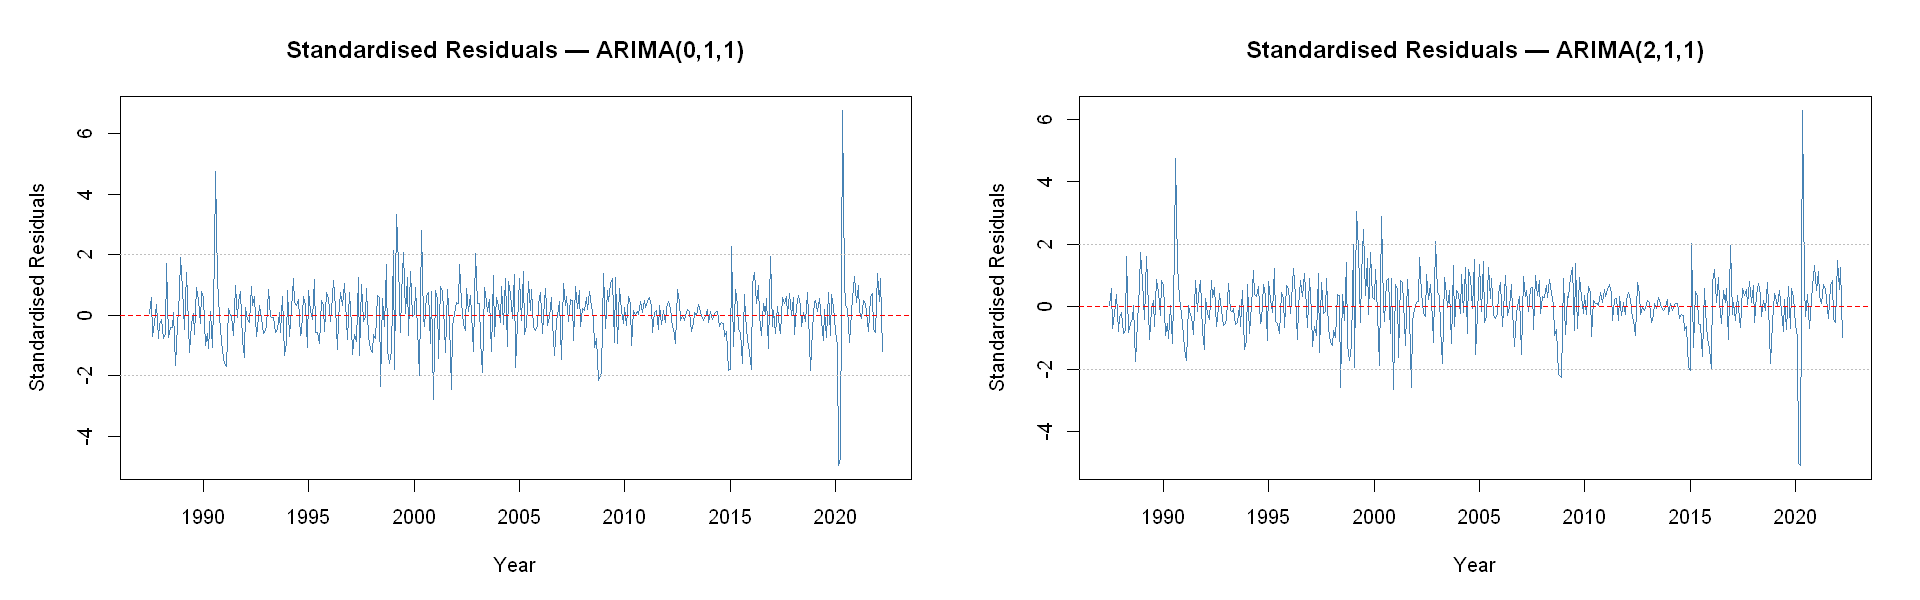

In [136]:
# Residuals
res_m1 <- residuals(m1)
res_m3 <- residuals(m3)

# Standardised residuals
std_m1 <- res_m1 / sd(res_m1)
std_m3 <- res_m3 / sd(res_m3)

# Plot standardised residuals 
options(repr.plot.width = 16, repr.plot.height = 5)

par(mfrow = c(1, 2),
    bg    = "white",
    mar   = c(5, 5, 4, 2))

plot(std_m1,
     main = "Standardised Residuals — ARIMA(0,1,1)",
     ylab = "Standardised Residuals",
     xlab = "Year",
     col  = "steelblue",
     lwd  = 1.2)
abline(h = 0,  col = "red", lty = 2)
abline(h =  2, col = "gray", lty = 3)
abline(h = -2, col = "gray", lty = 3)

plot(std_m3,
     main = "Standardised Residuals — ARIMA(2,1,1)",
     ylab = "Standardised Residuals",
     xlab = "Year",
     col  = "steelblue",
     lwd  = 1.2)
abline(h = 0,  col = "red", lty = 2)
abline(h =  2, col = "gray", lty = 3)
abline(h = -2, col = "gray", lty = 3)

par(mfrow = c(1, 1))

<span style="color: #1b8a3a;"><strong>Interpretation : Standardised Residuals</strong></span>

Both models produce residuals that fluctuate around zero with no
visible trend or pattern, which is consistent with white noise
behaviour. The majority of values fall within the ±2 band. Two
isolated spikes are visible in both plots around 1991 and 2020
 corresponding to the Gulf War price shock and the COVID-19
demand collapse respectively. These are extreme but isolated events
and do not reflect a systematic failure of either model.

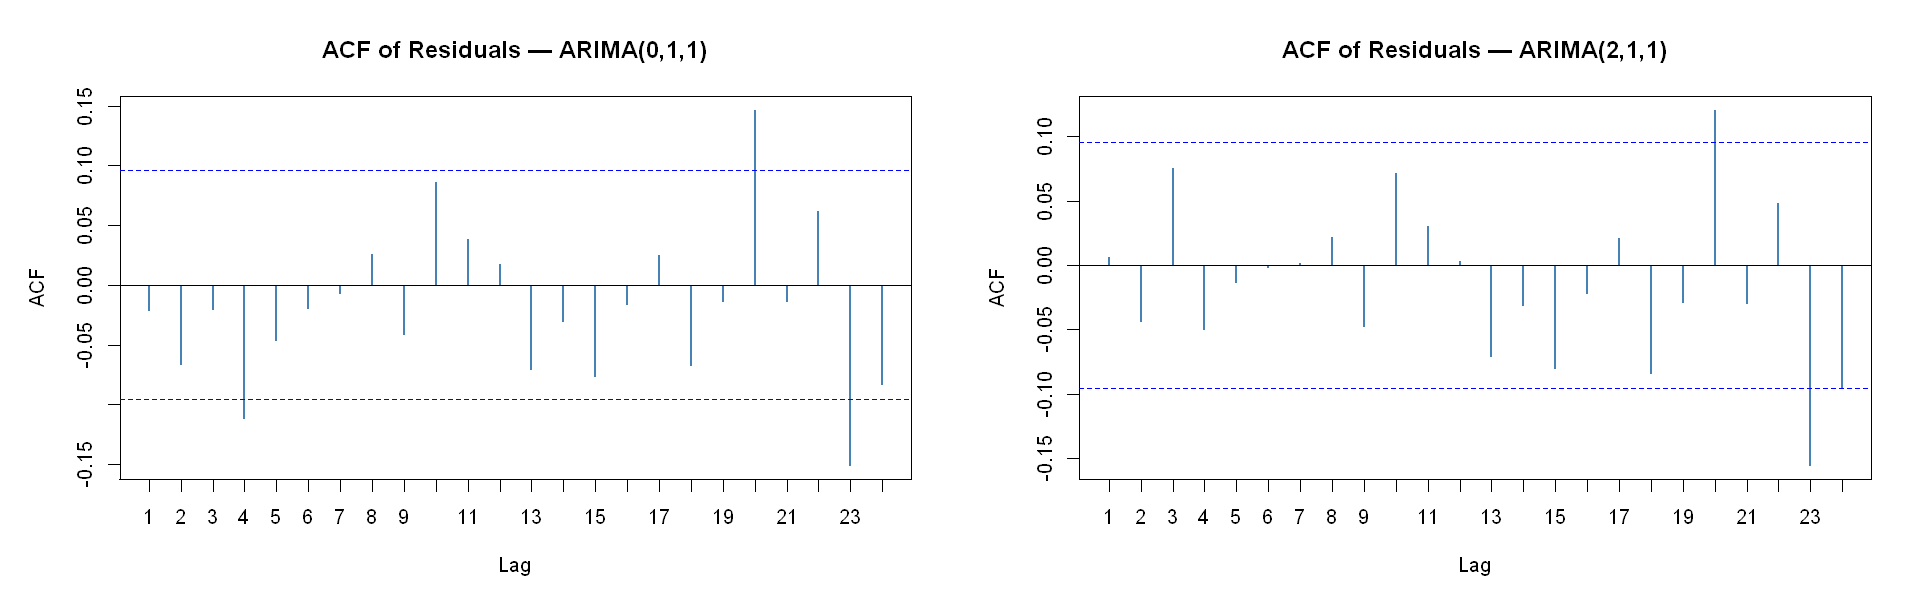

In [137]:
# ACF of residuals 
options(repr.plot.width = 16, repr.plot.height = 5)

par(mfrow = c(1, 2),
    bg    = "white",
    mar   = c(5, 5, 4, 2))

acf(res_m1,
    lag.max = 24,
    main    = "ACF of Residuals — ARIMA(0,1,1)",
    col     = "steelblue",
    lwd     = 2,
    xaxt    = "n")
axis(1, at = 0:24/12, labels = 0:24)

acf(res_m3,
    lag.max = 24,
    main    = "ACF of Residuals — ARIMA(2,1,1)",
    col     = "steelblue",
    lwd     = 2,
    xaxt    = "n")
axis(1, at = 0:24/12, labels = 0:24)

par(mfrow = c(1, 1))


<span style="color: #1b8a3a;"><strong>Interpretation : ACF of Residuals</strong></span>

The ACF plots of the residuals for both models show that most lags 
fall within the confidence bands, indicating that the majority of 
the autocorrelation structure has been captured.

**ARIMA(0,1,1):** Significant spikes remain at lags 4, 20 
and 23. These are not at regular intervals and are consistent 
with the distortion caused by the extreme price shocks of 2008 
and 2020 rather than genuine unmodeled autocorrelation structure.

**ARIMA(2,1,1):** Only lags 20 and 23 show borderline crossings. 
The residual ACF is noticeably cleaner than ARIMA(0,1,1), 
suggesting that the additional AR terms in ARIMA(2,1,1) capture 
some of the autocorrelation that ARIMA(0,1,1) leaves unmodeled.


In [138]:
# Ljung-Box test
lb_m1 <- Box.test(res_m1, lag = 20, type = "Ljung-Box")
lb_m3 <- Box.test(res_m3, lag = 20, type = "Ljung-Box")

cat("════════════════════════════════════════\n")
cat("Ljung-Box Test (lag = 20)\n")
cat("════════════════════════════════════════\n")
cat("ARIMA(0,1,1): X² =", round(lb_m1$statistic, 4),
    "  p-value =", round(lb_m1$p.value, 4), "\n")
cat("ARIMA(2,1,1): X² =", round(lb_m3$statistic, 4),
    "  p-value =", round(lb_m3$p.value, 4), "\n")
cat("════════════════════════════════════════\n")

════════════════════════════════════════
Ljung-Box Test (lag = 20)
════════════════════════════════════════
ARIMA(0,1,1): X² = 30.5534   p-value = 0.0614 
ARIMA(2,1,1): X² = 23.7938   p-value = 0.2515 
════════════════════════════════════════



<span style="color: #1b8a3a;"><strong>Interpretation : Ljung-Box Test</strong></span>
The null hypothesis H₀ states that the model is appropriate 
meaning the residuals are not autocorrelated up to lag 20.

| Model | X² | p-value | Decision |
|---|---|---|---|
| ARIMA(0,1,1) | 30.55 | 0.0614 | Fail to reject H₀  |
| ARIMA(2,1,1) | 23.79 | 0.2515 | Fail to reject H₀  |

Both p-values exceed 0.05, so H₀ is not rejected for either model.
The residuals of both models are consistent with white noise.
However, ARIMA(0,1,1) is borderline at p = 0.0614 just above the
threshold while ARIMA(2,1,1) is more comfortable at p = 0.2515,
suggesting its residuals are cleaner in terms of autocorrelation.

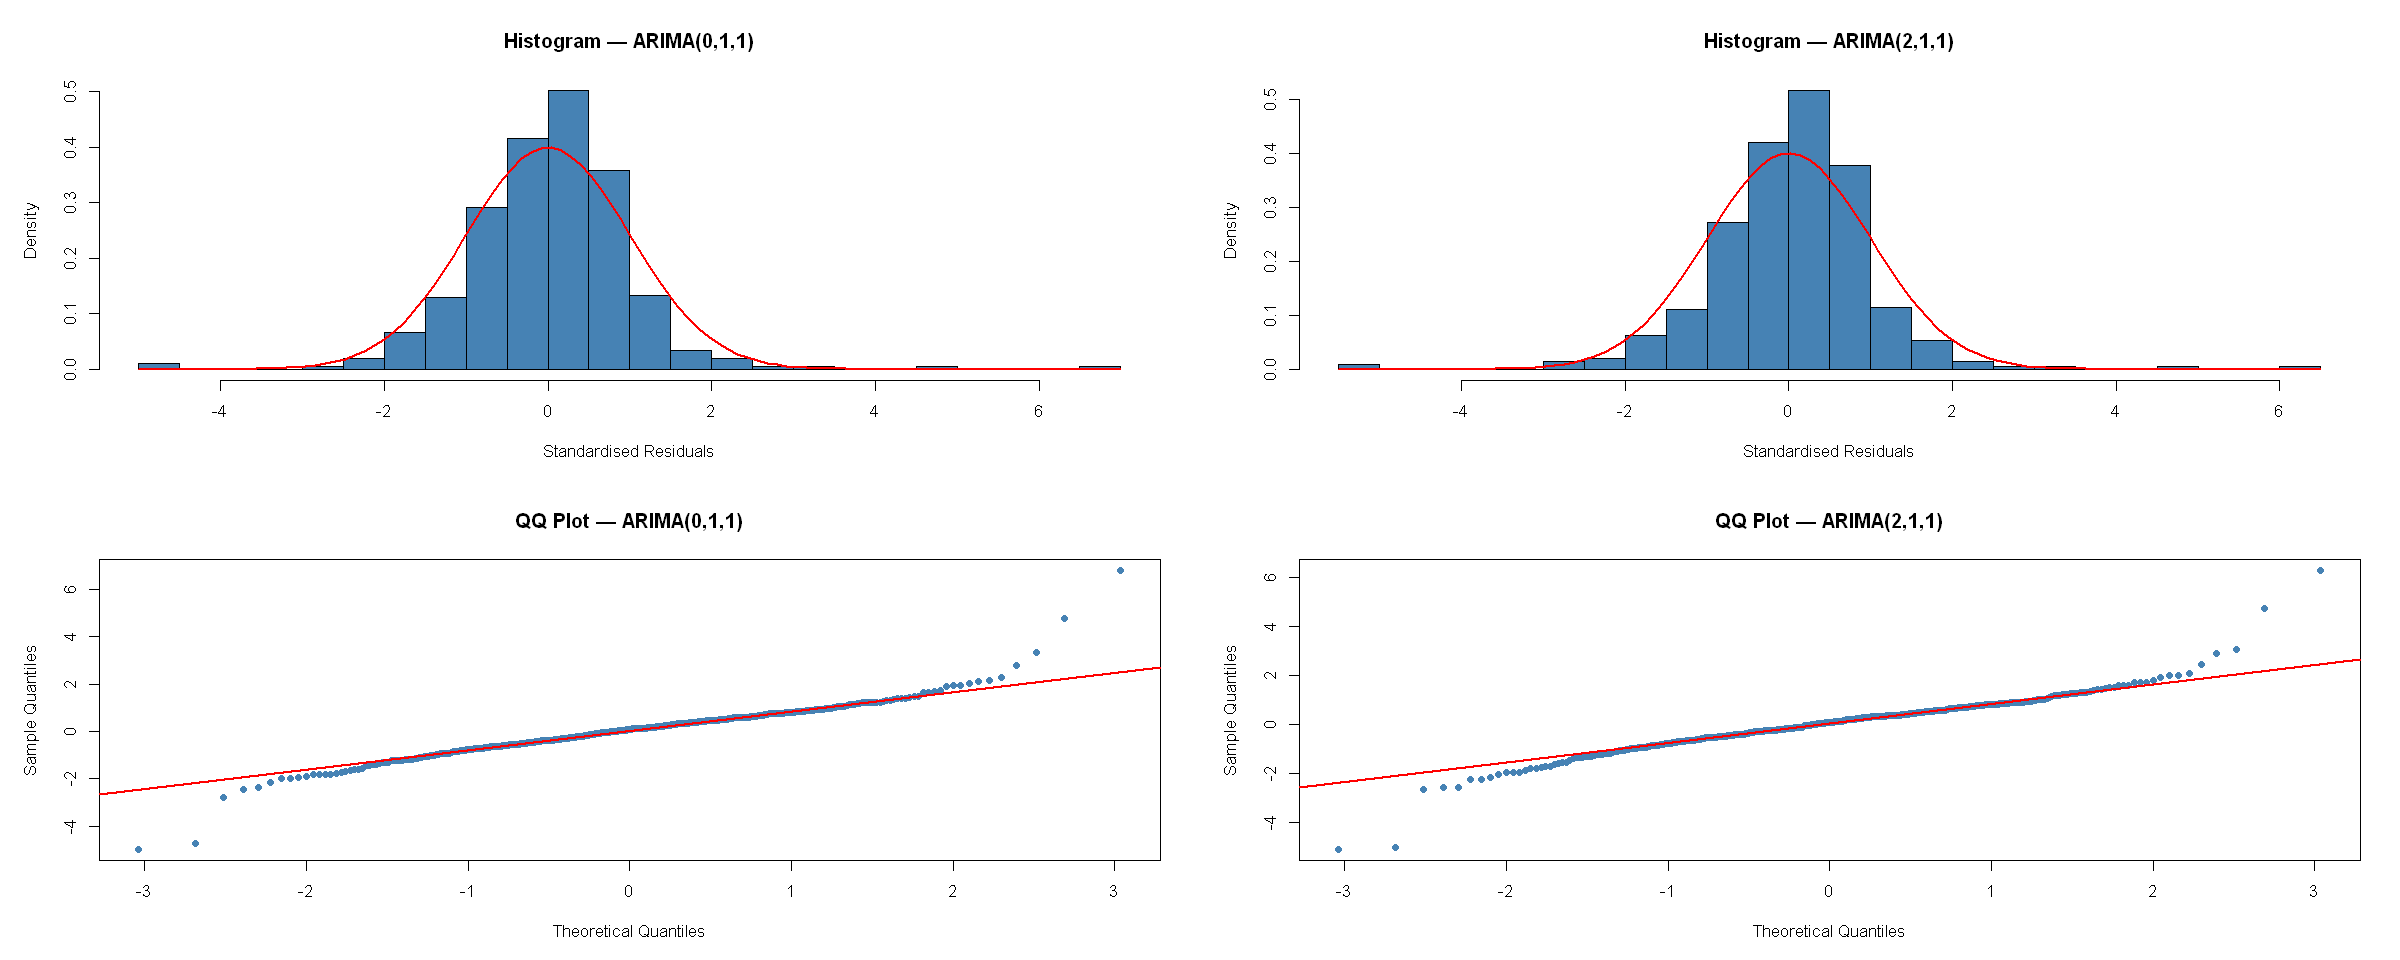

In [140]:
# Histogram and QQ plot 
options(repr.plot.width = 20, repr.plot.height = 8)

par(mfrow = c(2, 2),
    bg    = "white",
    mar   = c(5, 5, 4, 2))

# Histograms
hist(std_m1,
     breaks = 20,
     main   = "Histogram — ARIMA(0,1,1)",
     xlab   = "Standardised Residuals",
     col    = "steelblue",
     freq   = FALSE)
curve(dnorm(x), add = TRUE, col = "red", lwd = 2)

hist(std_m3,
     breaks = 20,
     main   = "Histogram — ARIMA(2,1,1)",
     xlab   = "Standardised Residuals",
     col    = "steelblue",
     freq   = FALSE)
curve(dnorm(x), add = TRUE, col = "red", lwd = 2)

# QQ plots
qqnorm(std_m1,
       main = "QQ Plot — ARIMA(0,1,1)",
       col  = "steelblue",
       pch  = 16)
qqline(std_m1, col = "red", lwd = 2)

qqnorm(std_m3,
       main = "QQ Plot — ARIMA(2,1,1)",
       col  = "steelblue",
       pch  = 16)
qqline(std_m3, col = "red", lwd = 2)

par(mfrow = c(1, 1))


<span style="color: #1b8a3a;"><strong>Interpretation Normality: Histogram and QQ Plot</strong></span>

Both histograms are centred around zero and roughly bell-shaped,
which suggests approximate normality in the centre of the distribution.
However, both are slightly right-skewed with a heavier right tail,
driven by extreme positive price shocks.

Both QQ plots show points close to the red diagonal in the middle,
but clear departures at both tails, especially the upper tail.
This indicates heavy tails and therefore imperfect normality for both models.
So, from visual diagnostics alone, normality is only approximate.
A formal confirmation must be done using the Shapiro-Wilk test in the next step.

In [142]:
# Shapiro-Wilk normality test 
sw_m1 <- shapiro.test(as.numeric(std_m1))
sw_m3 <- shapiro.test(as.numeric(std_m3))

cat("════════════════════════════════════════\n")
cat("Shapiro-Wilk Normality Test\n")
cat("════════════════════════════════════════\n")
cat("ARIMA(0,1,1): W =", round(sw_m1$statistic, 4),
    "  p-value =", round(sw_m1$p.value, 4), "\n")
cat("ARIMA(2,1,1): W =", round(sw_m3$statistic, 4),
    "  p-value =", round(sw_m3$p.value, 4), "\n")
cat("════════════════════════════════════════\n")

# Runs test (independence)
library(tseries)
runs_m1 <- runs.test(as.factor(std_m1 > 0))
runs_m3 <- runs.test(as.factor(std_m3 > 0))

cat("\n════════════════════════════════════════\n")
cat("Runs Test (Independence)\n")
cat("════════════════════════════════════════\n")
cat("ARIMA(0,1,1): p-value =", round(runs_m1$p.value, 4), "\n")
cat("ARIMA(2,1,1): p-value =", round(runs_m3$p.value, 4), "\n")
cat("════════════════════════════════════════\n")

════════════════════════════════════════
Shapiro-Wilk Normality Test
════════════════════════════════════════
ARIMA(0,1,1): W = 0.9195   p-value = 0 
ARIMA(2,1,1): W = 0.9226   p-value = 0 
════════════════════════════════════════

════════════════════════════════════════
Runs Test (Independence)
════════════════════════════════════════
ARIMA(0,1,1): p-value = 0.411 
ARIMA(2,1,1): p-value = 0.5999 
════════════════════════════════════════



<span style="color: #1b8a3a;"><strong>Interpretation : Shapiro-Wilk and Runs Test</strong></span>
**Shapiro-Wilk (Normality):**

| Model | W | p-value | Decision |
|---|---|---|---|
| ARIMA(0,1,1) | 0.9195 | < 0.001 | Reject H₀  |
| ARIMA(2,1,1) | 0.9226 | < 0.001 | Reject H₀  |

- Both models reject the null hypothesis of normality. This is consistent with what the QQ plots and histograms showed.
- The non-normality is likely driven by a few extreme observations during major market shocks, which create heavier tails.
- Heavy-tailed residuals are common in long real-world economic time series, especially when volatility changes abruptly over time.



**Runs Test (Independence):**

| Model | p-value | Decision |
|---|---|---|
| ARIMA(0,1,1) | 0.4110 | Fail to reject H₀  |
| ARIMA(2,1,1) | 0.5999 | Fail to reject H₀  |

Both p-values are well above 0.05. The null hypothesis of
independence is not rejected for either model ,the residuals show
no systematic runs pattern and can be considered independent

<br>
<br>


<h3 style="font-weight:800;">3.4 Summary of Diagnostics and Model Selection</h3>


The table below summarises the diagnostic results for both 
candidate models:

| Test | ARIMA(0,1,1) | ARIMA(2,1,1) |
|---|---|---|
| Ljung-Box p-value    | > 0.05 (pass) | > 0.05 (pass) |
| Runs test p-value    | 0.411 (pass)  | 0.600 (pass)  |
| Shapiro-Wilk p-value | approx. 0 (fail)    | approx. 0 (fail)    |
| Residual ACF clean   | Mostly     | Mostly     |
| AIC                | higher      | -1633.72  |
| BIC                  | -1624.42  | higher |

Both models satisfy the independence and uncorrelation 
requirements ,the Ljung-Box and Runs tests fail to reject 
the null hypothesis for both. However, both models **fail the 
Shapiro-Wilk normality** test with p-value approx. 0, indicating 
that the residuals are not normally distributed.

Since the normality assumption is violated, 
<span style="color: #c62828;"><strong>neither model can be considered fully adequate within the strict ARIMA framework</strong></span>. This failure is attributed to the heavy tails 
caused by the extreme price shocks of 2008 and 2020, which 
produce outliers that standard ARIMA cannot capture.

Since both models fail normality, the Ljung-Box and Runs 
test results cannot be used to choose between them. The 
comparison is based on AIC and BIC only. ARIMA(2,1,1) 
achieves the lower AIC while ARIMA(0,1,1) achieves the 
lower BIC. Applying the Principle of Parsimony, 
**ARIMA(0,1,1)** is selected as the final model , it uses 
fewer parameters and is supported by the BIC criterion and 
the restricted time window analysis.

<h3 style="font-weight:800;">3.4 Final Model Selection</h3>
Based on the diagnostic results, the AIC/BIC comparison, and 
the Principle of Parsimony,  <span style="color: #b83838;"><strong>ARIMA(0,1,1)</strong></span>  is selected as 
the final model for forecasting .Athough neither candidate 
model is strictly adequate due to the normality violation, 
ARIMA(0,1,1) is preferred as the simpler model supported by 
the BIC criterion and the restricted time window analysis. 
Forecasting is performed as a demonstration of the complete 
methodology, with results interpreted accordingly


	Ljung-Box test

data:  Residuals from ARIMA(0,1,1)
Q* = 45.585, df = 23, p-value = 0.003367

Model df: 1.   Total lags used: 24



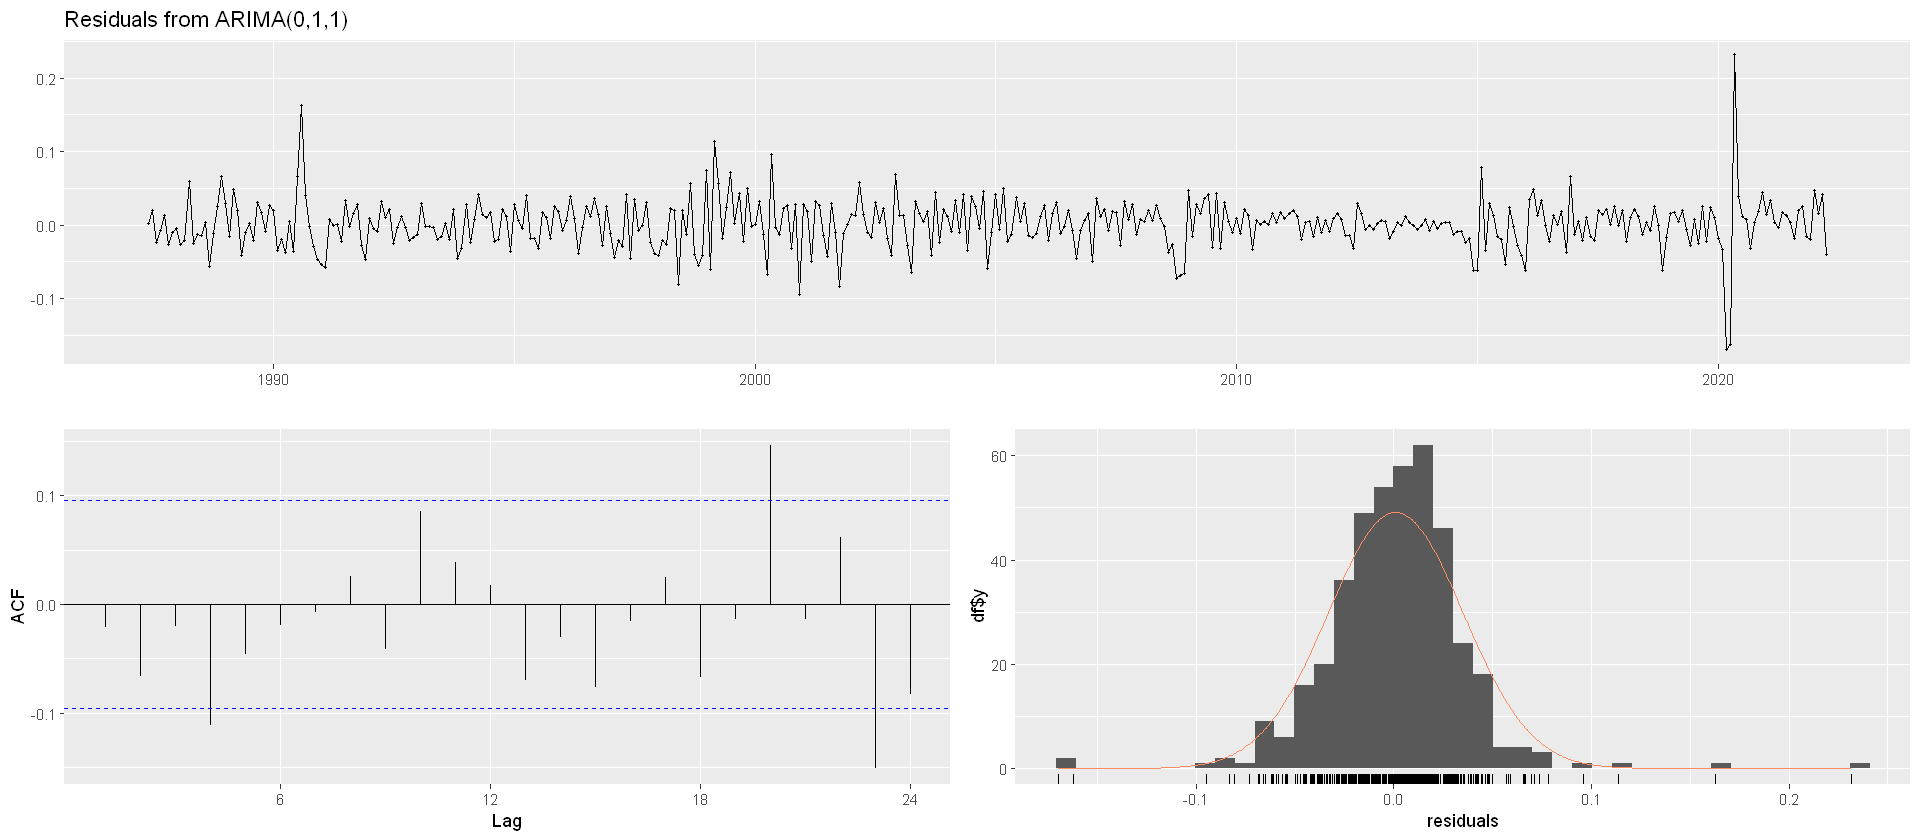

In [170]:
checkresiduals(m1, lag.max = 24, main = "ARIMA(0,1,1) Residual Diagnostics")


<h3 style="font-weight:800;">3.5 Model Deficiencies</h3>
The final ARIMA(0,1,1) model presents the following deficiencies:

- **Non-normality:** the model fails the Shapiro-Wilk test due 
to heavy tails from the 2008 and 2020 price shocks. 

- **Volatility clustering:** Residual variance is not constant — 
high volatility periods cluster together, violating the constant 
variance assumption. A GARCH extension would address this but 
falls outside the scope of this study.

- **Flat forecasts:** With no AR component, ARIMA(0,1,1) forecasts 
beyond step 1 collapse to a constant level.

Despite these limitations, forecasting is performed as a 
demonstration of the full methodology. Results should be 
interpreted with caution, particularly the prediction intervals.

## **4. Forecasting**

This section uses the final model ARIMA(0,1,1) fitted on the 
Box-Cox transformed training series  to generate forecasts for 
the 46 withheld test observations. Forecasts are produced on the 
transformed scale and then back-transformed to the original dollar 
scale using the inverse Box-Cox transformation. The forecasting 
performance is evaluated by comparing predicted values to the 
actual withheld prices using RMSE and MAE.



<h3 style="font-weight:800;">4.1 Generating Forecasts</h3>


In [163]:
# Refit final model on training set 
final_model <- arima(train_bc, order = c(0, 1, 1))

# Forecast 46 steps ahead 
h <- length(test_ts)
fc <- predict(final_model, n.ahead = h)

# Back-transform using inverse Box-Cox 
fc_mean  <- InvBoxCox(fc$pred, lambda = lambda_result)
fc_upper <- InvBoxCox(fc$pred + 1.96 * fc$se,
                      lambda = lambda_result)
fc_lower <- InvBoxCox(fc$pred - 1.96 * fc$se,
                      lambda = lambda_result)

# Print forecast vs actual table

cat("════════════════════════════════════════════════\n")
cat(sprintf("%-10s %8s %8s %8s %8s\n",
            "Month", "Actual", "Forecast",
            "Lower95", "Upper95"))
cat("────────────────────────────────────────────────\n")

for (i in 1:h) {
  cat(sprintf("%-10s %8.2f %8.2f %8.2f %8.2f\n",
              as.character(round(time(test_ts)[i], 3)),
              as.numeric(test_ts)[i],
              as.numeric(fc_mean)[i],
              as.numeric(fc_lower)[i],
              as.numeric(fc_upper)[i]))
}
cat("════════════════════════════════════════════════\n")

════════════════════════════════════════════════
Month        Actual Forecast  Lower95  Upper95
────────────────────────────────────────────────
2022.333     113.34    99.57    77.07   131.42
2022.417     122.71    99.57    66.03   159.11
2022.5       111.93    99.57    59.44   183.39
2022.583     100.45    99.57    54.66   207.00
2022.667      89.76    99.57    50.92   230.78
2022.75       93.33    99.57    47.84   255.18
2022.833      91.42    99.57    45.24   280.50
2022.917      80.92    99.57    42.99   306.95
2023          82.50    99.57    41.01   334.73
2023.083      82.59    99.57    39.25   363.99
2023.167      78.43    99.57    37.67   394.92
2023.25       84.64    99.57    36.24   427.68
2023.333      75.47    99.57    34.94   462.44
2023.417      74.84    99.57    33.74   499.39
2023.5        80.11    99.57    32.64   538.72
2023.583      86.15    99.57    31.62   580.63
2023.667      93.72    99.57    30.67   625.35
2023.75       90.60    99.57    29.78   673.11
2023.833 

<h3 style="font-weight:800;">4.2 Forecast Accuracy</h3>


In [169]:
# Forecast accuracy metrics using built-in function from forecast package
acc <- forecast::accuracy(fc_mean, test_ts)

cat("════════════════════════════════════\n")
cat("FORECAST ACCURACY METRICS (accuracy)\n")
cat("════════════════════════════════════\n")

metric_cols <- intersect(c("ME", "RMSE", "MAE", "MPE", "MAPE", "MASE"), colnames(acc))
print(round(acc[, metric_cols, drop = FALSE], 4))

cat("════════════════════════════════════\n")

# Coverage: how many actuals inside 95% PI
inside <- sum(as.numeric(test_ts) >= as.numeric(fc_lower) &
              as.numeric(test_ts) <= as.numeric(fc_upper))
cat("Observations inside 95% PI:",
    inside, "out of", h, "\n")

════════════════════════════════════
FORECAST ACCURACY METRICS (accuracy)
════════════════════════════════════
              ME    RMSE     MAE      MPE    MAPE
Test set -18.563 22.5004 20.7426 -25.6268 27.4925
════════════════════════════════════


Observations inside 95% PI: 46 out of 46 


<span style="color: #1b8a3a;"><strong>Interpretation of metrics</strong></span>

 The model tends to over-forecast in the test period (ME and MPE are negative), which matches the post-2022 decline seen in actual prices. 


- **RMSE (22.50):** The root mean squared error indicates the model's average prediction error is **22.50** dollars per barrel.
- **MAE (20.74):** The mean absolute error shows that the model's average error magnitude is **20.74** dollars per barrel.
- **MAPE (27.49%):** The mean absolute percentage error of **27.49%** reflects significant forecasting challenges due to the model's inability to capture sharp price movements.

 Error size is relatively high so point forecasts are not very precise. However, 46/46 observations fall inside the 95% interval, meaning uncertainty is captured, but with wide and conservative intervals.

<h3 style="font-weight:800;">4.3 Forecast Plot</h3>


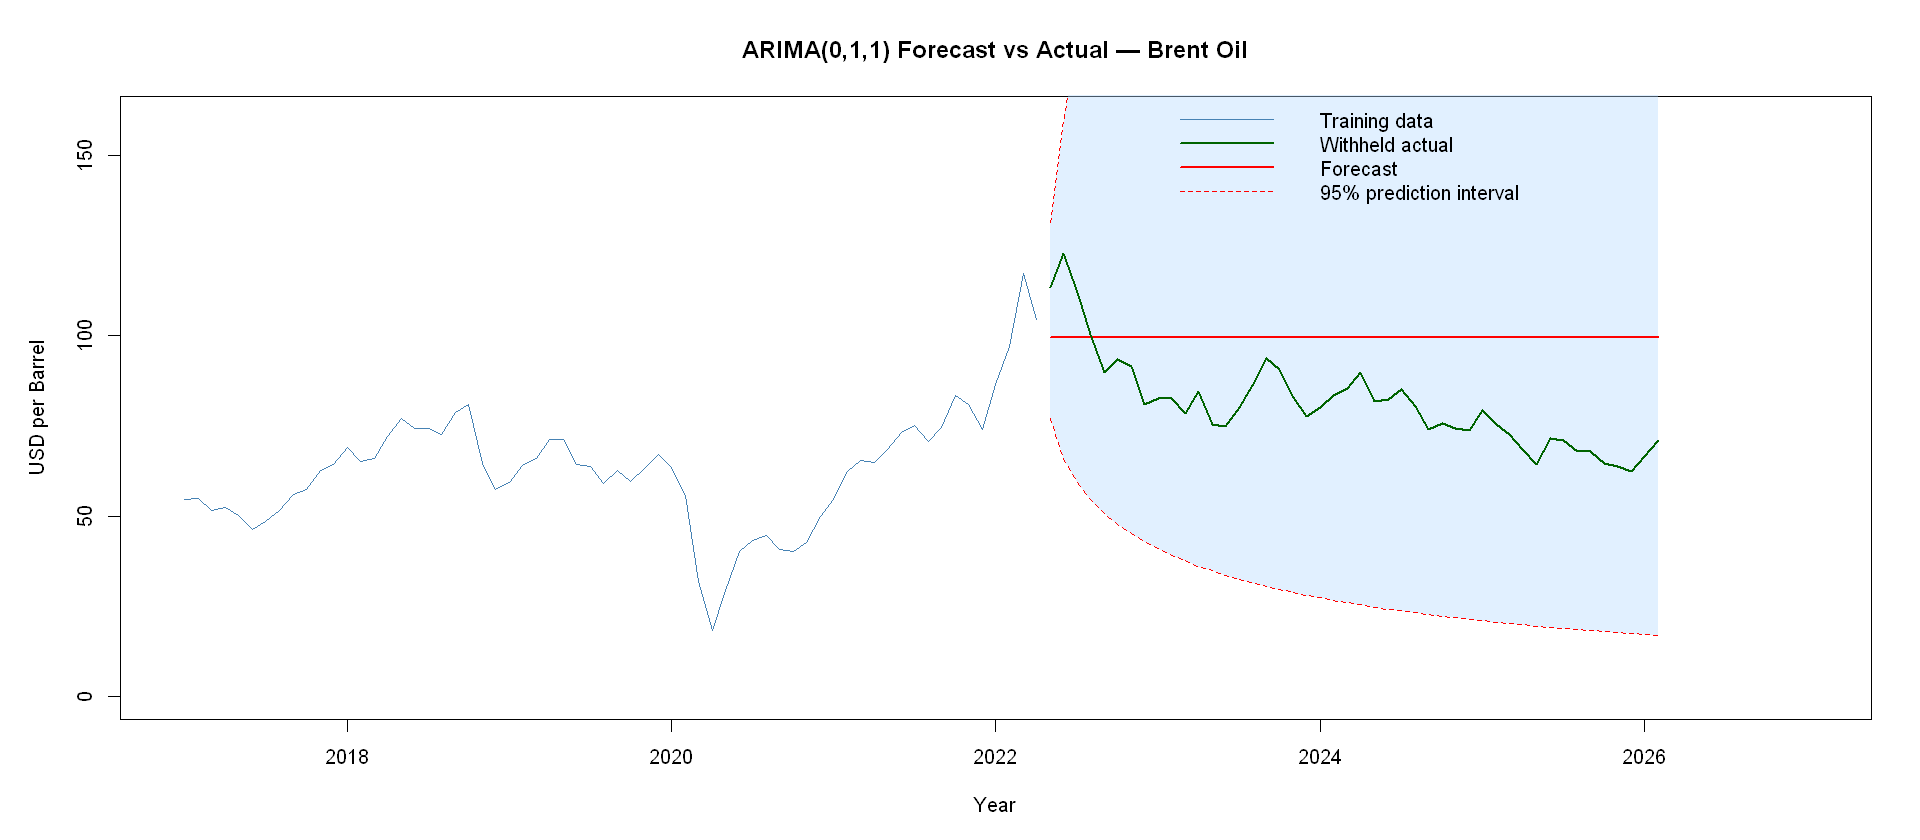

In [165]:
# Forecast plot 
options(repr.plot.width = 16, repr.plot.height = 7)

# Show last 5 years of training for clarity
train_recent <- window(train_ts, start = c(2017, 1))

# Convert forecasts to ts objects
fc_ts    <- ts(fc_mean,  start = start(test_ts), frequency = 12)
fc_up_ts <- ts(fc_upper, start = start(test_ts), frequency = 12)
fc_lo_ts <- ts(fc_lower, start = start(test_ts), frequency = 12)

par(bg  = "white",
    mar = c(5, 5, 4, 2))

plot(train_recent,
     main = "ARIMA(0,1,1) Forecast vs Actual — Brent Oil",
     ylab = "USD per Barrel",
     xlab = "Year",
     col  = "steelblue",
     lwd  = 1.5,
     xlim = c(2017, 2027),
     ylim = c(0, 160))

# Prediction interval shading
polygon(c(time(fc_up_ts), rev(time(fc_lo_ts))),
        c(as.numeric(fc_up_ts), rev(as.numeric(fc_lo_ts))),
        col    = rgb(0.7, 0.85, 1, alpha = 0.4),
        border = NA)

# Forecast line
lines(fc_ts, col = "red", lwd = 2)

# Actual withheld values
lines(test_ts, col = "darkgreen", lwd = 2)

# PI borders
lines(fc_up_ts, col = "red", lwd = 1, lty = 2)
lines(fc_lo_ts, col = "red", lwd = 1, lty = 2)

legend("topright",
       legend = c("Training data",
                  "Withheld actual",
                  "Forecast",
                  "95% prediction interval"),
       col    = c("steelblue", "darkgreen", "red", "red"),
       lwd    = c(1.5, 2, 2, 1),
       lty    = c(1, 1, 1, 2),
       bty    = "n")

<span style="color: #1b8a3a;"><strong>Interpretation Of Results</strong></span>

The forecast from ARIMA(0,1,1) is higher than the real prices in the test period. After the Ukraine-war peak, actual Brent prices kept going down, but the model produced an almost flat path around the last smoothed training value. This shows the main limitation of this model. The prediction interval becomes wider as the forecast horizon increases, which means uncertainty grows over time. Even though all test observations stay inside the 95% interval, the model still does not capture the true post-2022 price normalization accurately.


## **5. Discussion**

This project applied the full ARIMA modeling methodology to 
monthly Brent Crude Oil prices covering June 1987 to February 
2026.

<span style="color: #5c8b6a; font-weight: 800;">**Summary of steps:**</span>
- The raw series exhibited a non-constant 
mean and growing variance, confirmed visually and by the ADF 
test. 
- A Box-Cox transformation with λ = -0.3 stabilized the 
variance, and first-order differencing achieved stationarity 
- ACF and PACF analysis of the stationary 
series identified five candidate ARIMA(p,1,q) models.
-  These 
were fitted and compared using AIC and BIC, with ARIMA(2,1,1) 
achieving the lowest AIC and ARIMA(0,1,1) the lowest BIC. 
- Applying the Principle of Parsimony, ARIMA(0,1,1) was selected 
as the final model.

<span style="color: #5c8b6a; font-weight: 800;">**Main findings:**</span>
- Residual diagnostics revealed that both 
candidate models satisfy the independence and uncorrelation 
requirements but fail the normality assumption due to heavy 
tails caused by the 2008 financial crisis and 2020 COVID-19 
crash. 
- As a result <span style="color: #c62828;">**, neither model is strictly adequate under the ARIMA framework.**</span>
- Forecasting was performed as a 
demonstration of the methodology. The flat forecast systematically overestimated the actual declining prices.

<span style="color: #5c8b6a; font-weight: 800;">**Problems encountered:**</span>

- The primary challenge was the 
presence of extreme outliers from two major global crises, 
which distorted the ACF/PACF patterns and prevented the 
residuals from satisfying the normality assumption. 
- These issues are inherent to 
commodity price data and suggest that models beyond the 
ARIMA class would be more appropriate for this series.

<span style="color: #5c8b6a; font-weight: 800;">**Real-world context:**</span>
- From a real-world perspective, the results confirm that 
standard ARIMA models struggle to forecast commodity prices 
driven by geopolitical shocks. 
- For oil-dependent economies like Algeria, this 
highlights the difficulty of budget planning when prices are subject to sudden and 
unpredictable structural shifts.

*Delivered By:* **Khadraoui Afaf**